## Compare all models
Compare the constraining power of different volumes of data on the model parameters.

In [1]:
%load_ext autoreload
%autoreload 2

%matplotlib inline

import os
from os.path import join
import json
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
mpl.style.use('../../style.mcstyle')   # noqa
import numpy as np
import torch
import seaborn as sns
import pandas as pd
import warnings
from tqdm import tqdm

from tools import torch_device

device = torch_device()

# Suppress warnings
warnings.filterwarnings('ignore')

Duplicate key in file '../../style.mcstyle', line 16 ('font.family: serif')


CUDA is not available. Using CPU.


## Plot constraining power as a function of survey volume

In [2]:
wdir = '/anvil/scratch/x-mho1/cmass-ili'

cosmonames = [r'$\Omega_m$', r'$\Omega_b$', r'$h$', r'$n_s$', r'$\sigma_8$']
hodnames = [r'$\alpha$', r'$\log M_0$', r'$\log M_1$',
            r'$\log M_{\min}$', r'$\sigma_{\log M}$']
names = cosmonames  # +hodnames

kmin, kmax = 0.0, 0.4

In [4]:
# ~~~~~~~~~~~~ LIGHTCONE EXPERIMENTS ~~~~~~~~~~~~
suites = ['abacuslike', 'abacuslike', 'abacuslike']  # , 'mtnglike']
sims = ['fastpm_recnoise']*3
tracers = ['simbig_lightcone', 'sgc_lightcone', 'mtng_lightcone']
summlist = [
    # ['nbar', 'Pk0'],
    ['nbar', 'nz', 'Pk0'],
    # ['nbar', 'Pk0', 'Pk2', 'Pk4'],
    ['nbar', 'nz', 'Pk0', 'Pk2', 'Pk4'],
    # ['nbar', 'Pk0', 'Pk2', 'Pk4', 'EqQk0'],
    ['nbar', 'nz', 'Pk0', 'Pk2', 'Pk4', 'EqQk0'],
    # ['nbar', 'Pk0', 'Pk2', 'Pk4', 'Qk0'],
    ['nbar', 'nz', 'Pk0', 'Pk2', 'Pk4', 'Qk0']
]
boxvols = (np.array([2000, 2750, 2000, 3500])/1e3)**3  # for diagnostics
vols = np.array([0.404, 1.251, 3.358, 3.562])  # (Gpc/h)^3

# # ~~~~~~~~~~~~ GALAXY EXPERIMENTS ~~~~~~~~~~~~
# suites = ['quijote', 'abacuslike', 'mtnglike']  # , 'mtnglike']
# sims = ['nbody', 'fastpm_hodzbias', 'fastpm_hodzbias']
# tracers = ['galaxy']*3
# summlist = [
#     ['nbar', 'zPk0'],
#     ['nbar', 'zPk0', 'zPk2', 'zPk4'],
#     ['nbar', 'zPk0', 'zPk2', 'zPk4', 'zQk0'],
# ]
# vols = np.array([1, 2, 3])**3  # (Gpc/h)^3

In [5]:

summarylist = ['+'.join(s) for s in summlist]
summaries = '+'.join(summarylist)  # For check later
keys = [f'{s}_{t}' for s, t in zip(suites, tracers)]

xtestdict, ytestdict, sampsdict, percsdict = {}, {}, {}, {}
for summary in tqdm(summarylist):
    # Use dictionaries to store data keyed by suite name
    xtestdict[summary], ytestdict[summary], sampsdict[summary], percsdict[summary] = {
    }, {}, {}, {}
    for i, s in enumerate(suites):
        # Specify model configuration
        nbody = s
        tracer = tracers[i]
        sim = sims[i]
        save_dir = join(wdir, nbody, sim, 'models')
        modelpath = join(save_dir, tracer, summary, f'kmin-{kmin}_kmax-{kmax}')

        if not os.path.exists(join(modelpath, 'posterior_samples.npy')):
            # This print statement is kept as it provides useful feedback
            print(f'Model path {modelpath} does not exist, skipping...')
            continue

        # Load predictions
        xtest = np.load(join(modelpath, 'x_test.npy'))[:, -10:]
        ytest = np.load(join(modelpath, 'theta_test.npy'))
        samps = np.load(join(modelpath, 'posterior_samples.npy'))
        percs = np.percentile(samps, [16, 50, 84], axis=0)

        key = f'{nbody}_{tracer}'
        xtestdict[summary][key] = xtest
        ytestdict[summary][key] = ytest
        sampsdict[summary][key] = samps
        percsdict[summary][key] = percs

# This calculation uses 'ytest' from the last successfully loaded file,
# which matches the original script's behavior.
if 'ytest' in locals():
    yrange = np.stack([
        ytest.min(axis=0),
        ytest.max(axis=0)
    ], axis=1)

 50%|█████     | 2/4 [00:01<00:01,  1.12it/s]

Model path /anvil/scratch/x-mho1/cmass-ili/abacuslike/fastpm_recnoise/models/simbig_lightcone/nbar+nz+Pk0+Pk2+Pk4+EqQk0/kmin-0.0_kmax-0.4 does not exist, skipping...


 75%|███████▌  | 3/4 [00:02<00:00,  1.31it/s]

Model path /anvil/scratch/x-mho1/cmass-ili/abacuslike/fastpm_recnoise/models/simbig_lightcone/nbar+nz+Pk0+Pk2+Pk4+Qk0/kmin-0.0_kmax-0.4 does not exist, skipping...


100%|██████████| 4/4 [00:03<00:00,  1.33it/s]


Text(0.5, 0.98, 'abacuslike, mtng_lightcone,  nbar+nz+Pk0+Pk2+Pk4+Qk0')

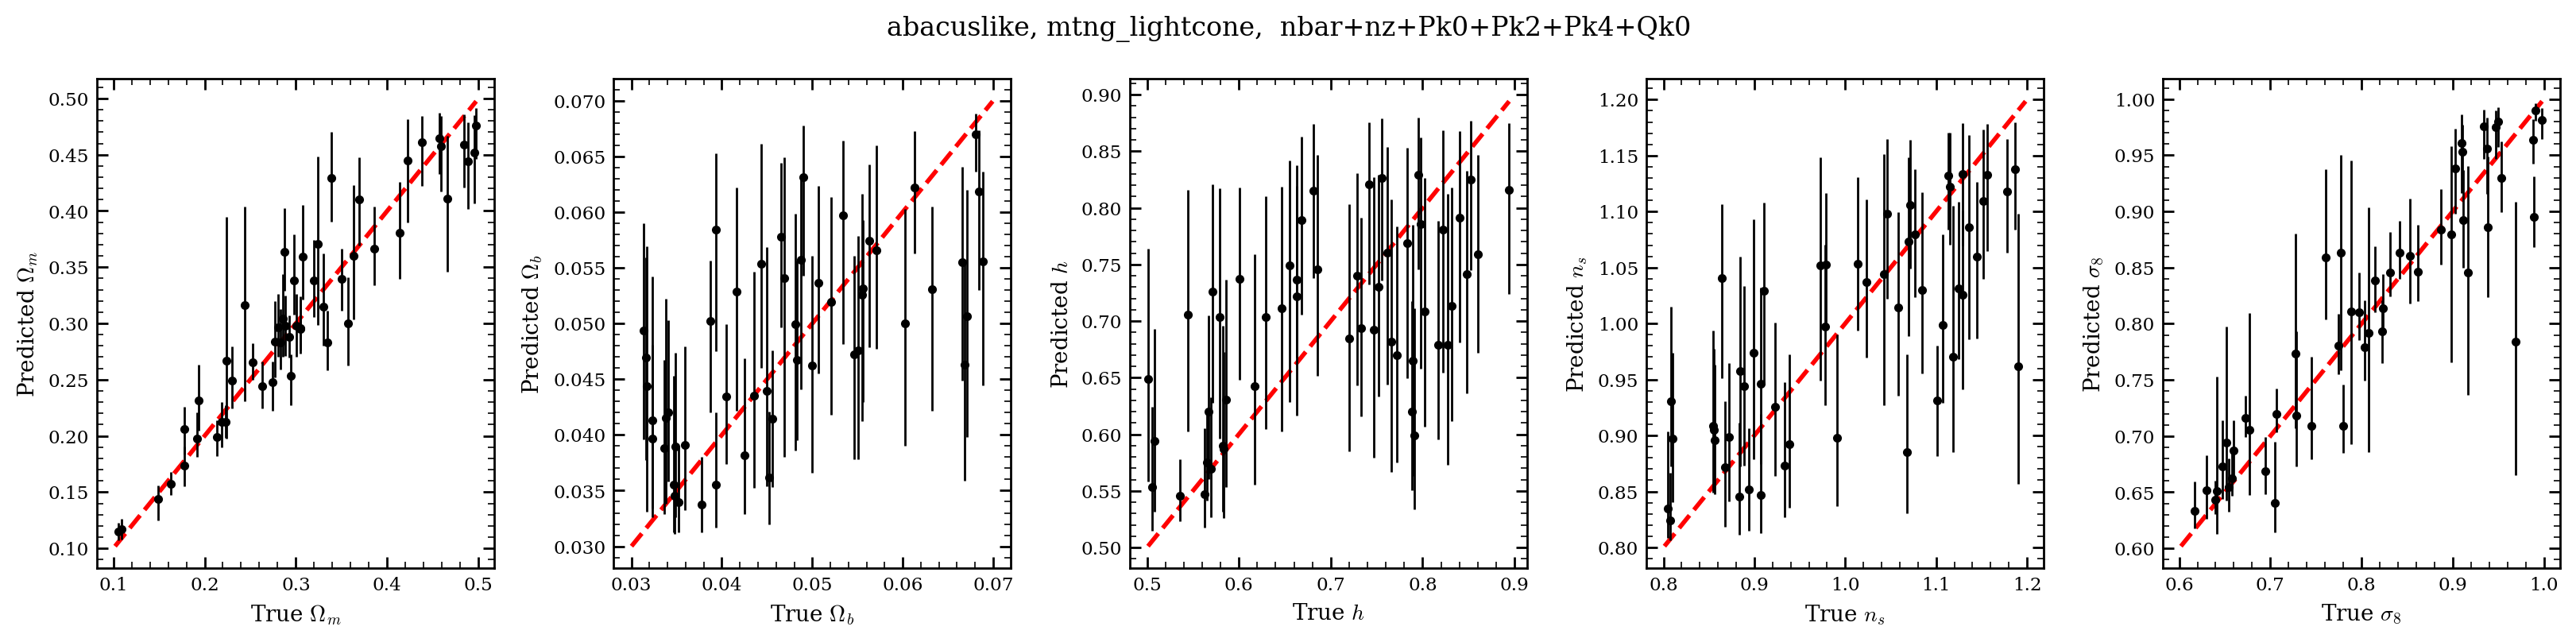

In [6]:
ss = 20

N = len(names)
H, W = N//5, 5
f, axs = plt.subplots(H, W, figsize=(4*W, 4*H), gridspec_kw=dict(wspace=0.3))
axs = axs.flatten()

for i, ax in enumerate(axs):
    if i >= N:
        ax.axis('off')
        continue
    ax.plot(yrange[i], yrange[i], 'r--')
    ax.plot(ytest[::ss, i], percs[1, ::ss, i], 'k.')
    ax.errorbar(ytest[::ss, i], percs[1, ::ss, i], yerr=[percs[1, ::ss, i]-percs[0, ::ss, i],
                percs[2, ::ss, i]-percs[1, ::ss, i]], fmt='none', ecolor='k', elinewidth=1)
    ax.set(xlabel=f'True {names[i]}', ylabel=f'Predicted {names[i]}')
f.suptitle(f'{nbody}, {tracer},  {summary}')

Text(0.5, 0.98, 'mtng_lightcone, nbar+nz+Pk0+Pk2+Pk4+Qk0 w/o BBN prior')

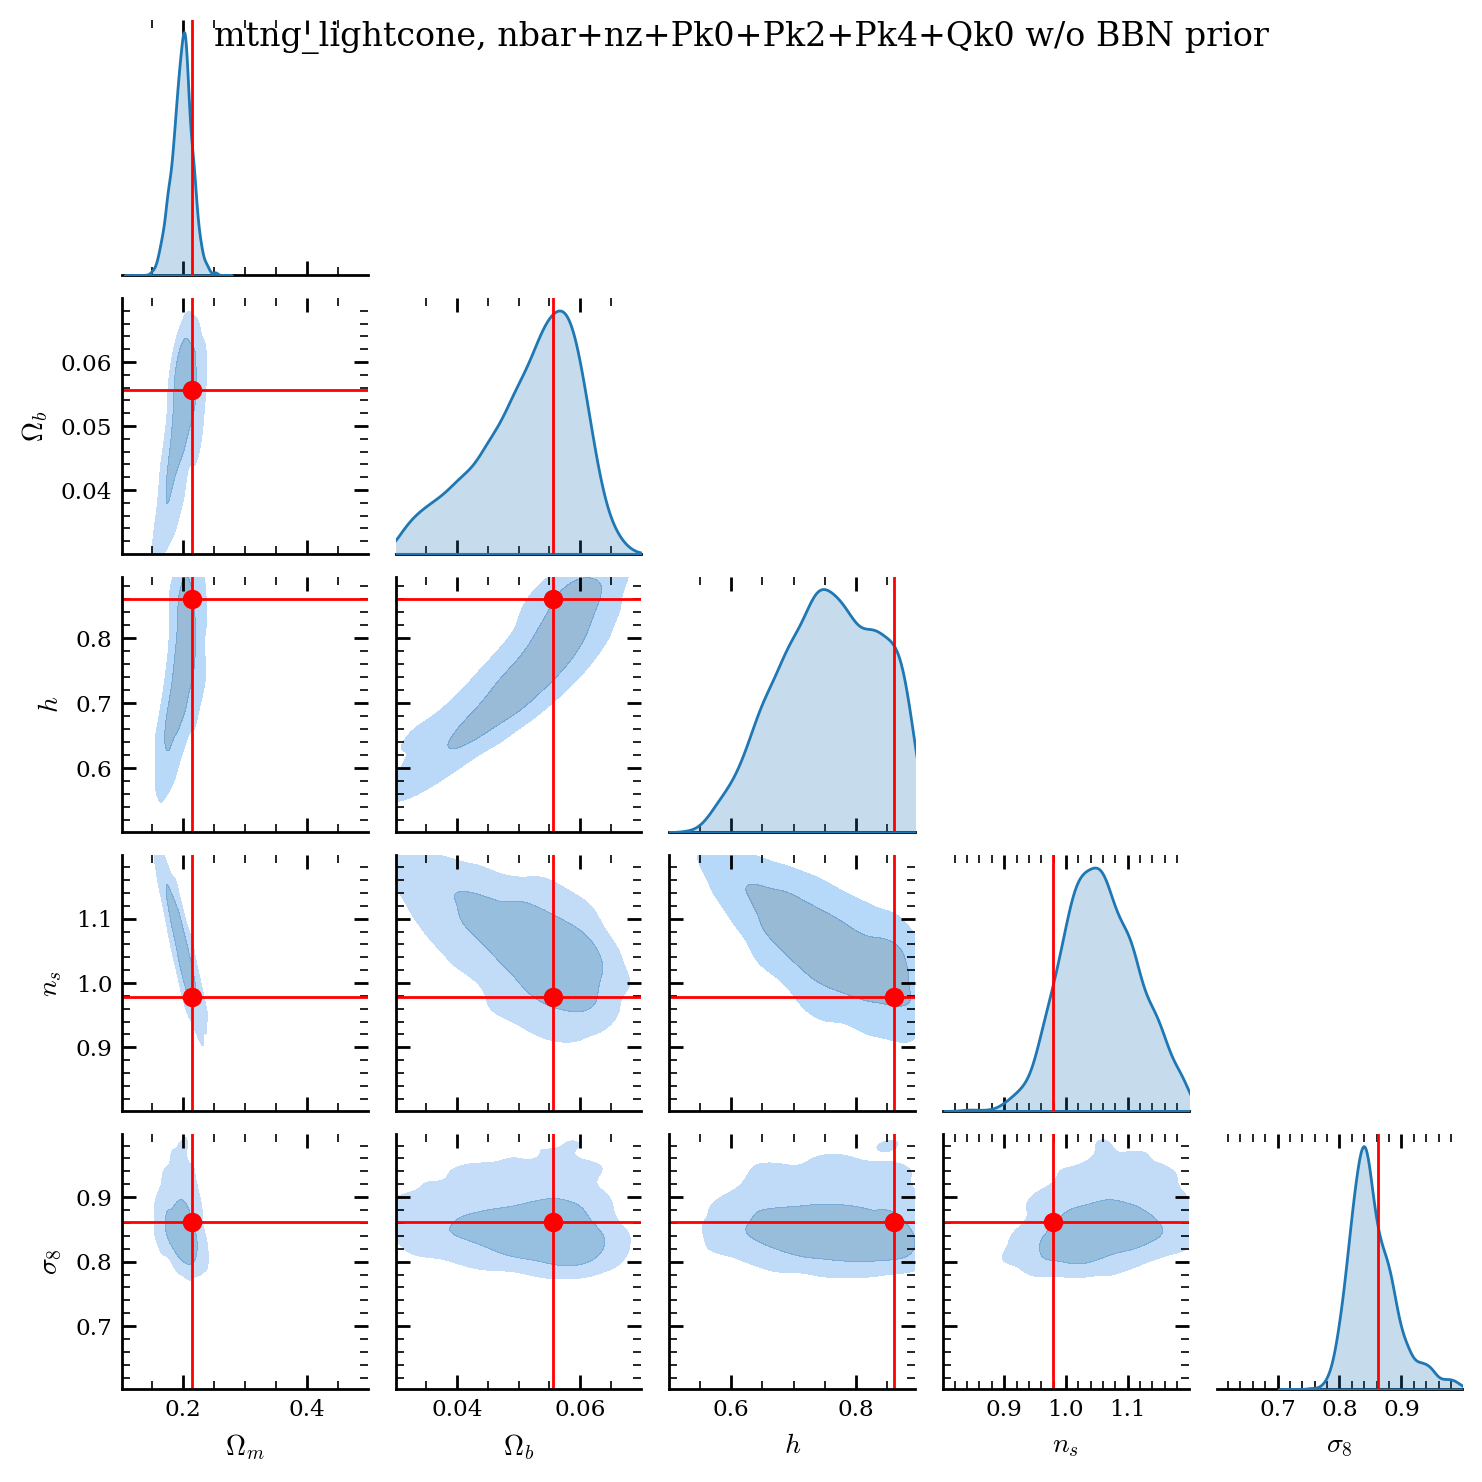

In [20]:
from tools import plot_true_vals, set_boundaries

# Predict on a random test point
ind = 0
samp0 = samps[:, ind, :len(names)]
samp0 = pd.DataFrame(samp0, columns=names)

yrange = np.stack([
    ytest.min(axis=0),
    ytest.max(axis=0)
], axis=1)


weights = None

# # Set a BBN prior for n_s
# ns_prior_mean = ytest[ind, 3]  # Center of the prior (true value)
# ns_prior_width = 0.0042        # Width (sigma) of the prior
# ns_samples = samp0.iloc[:, 3]
# weights = np.exp(-0.5 * ((ns_samples - ns_prior_mean) / ns_prior_width)**2)


# --- Plotting with Weights ---
g = sns.pairplot(
    samp0,
    vars=names,
    kind='kde',
    plot_kws={
        'alpha': 0.5,
        'levels': [0.05, 0.36, 1],
        'fill': True,
        'common_norm': False,
        'weights': weights  # Pass the calculated weights here
    },
    corner=True,
    height=1.5
)
plot_true_vals(g, ytest[ind, :len(names)], color='r', lw=1)
set_boundaries(g, yrange[:len(names)])

g.fig.suptitle(f'{tracer}, {summary}' +
               (' w/BBN prior' if weights is not None else ' w/o BBN prior'))

In [21]:
# Load literature data
lit_path = join(wdir, 'literature', 'processed')

# SimBIG zPk024
filename = join(lit_path, 'simbig_pk.csv')
simpk = pd.read_csv(filename)
simpk.columns = names
simpk['Model'] = 'SimBIG zPk024'

# SimBIG zQk0
filename = join(lit_path, 'simbig_bk.csv')
simbk = pd.read_csv(filename)
simbk.columns = names
simbk['Model'] = 'SimBIG zQk0'

# print(simpk.shape, simbk.shape)
# simbk

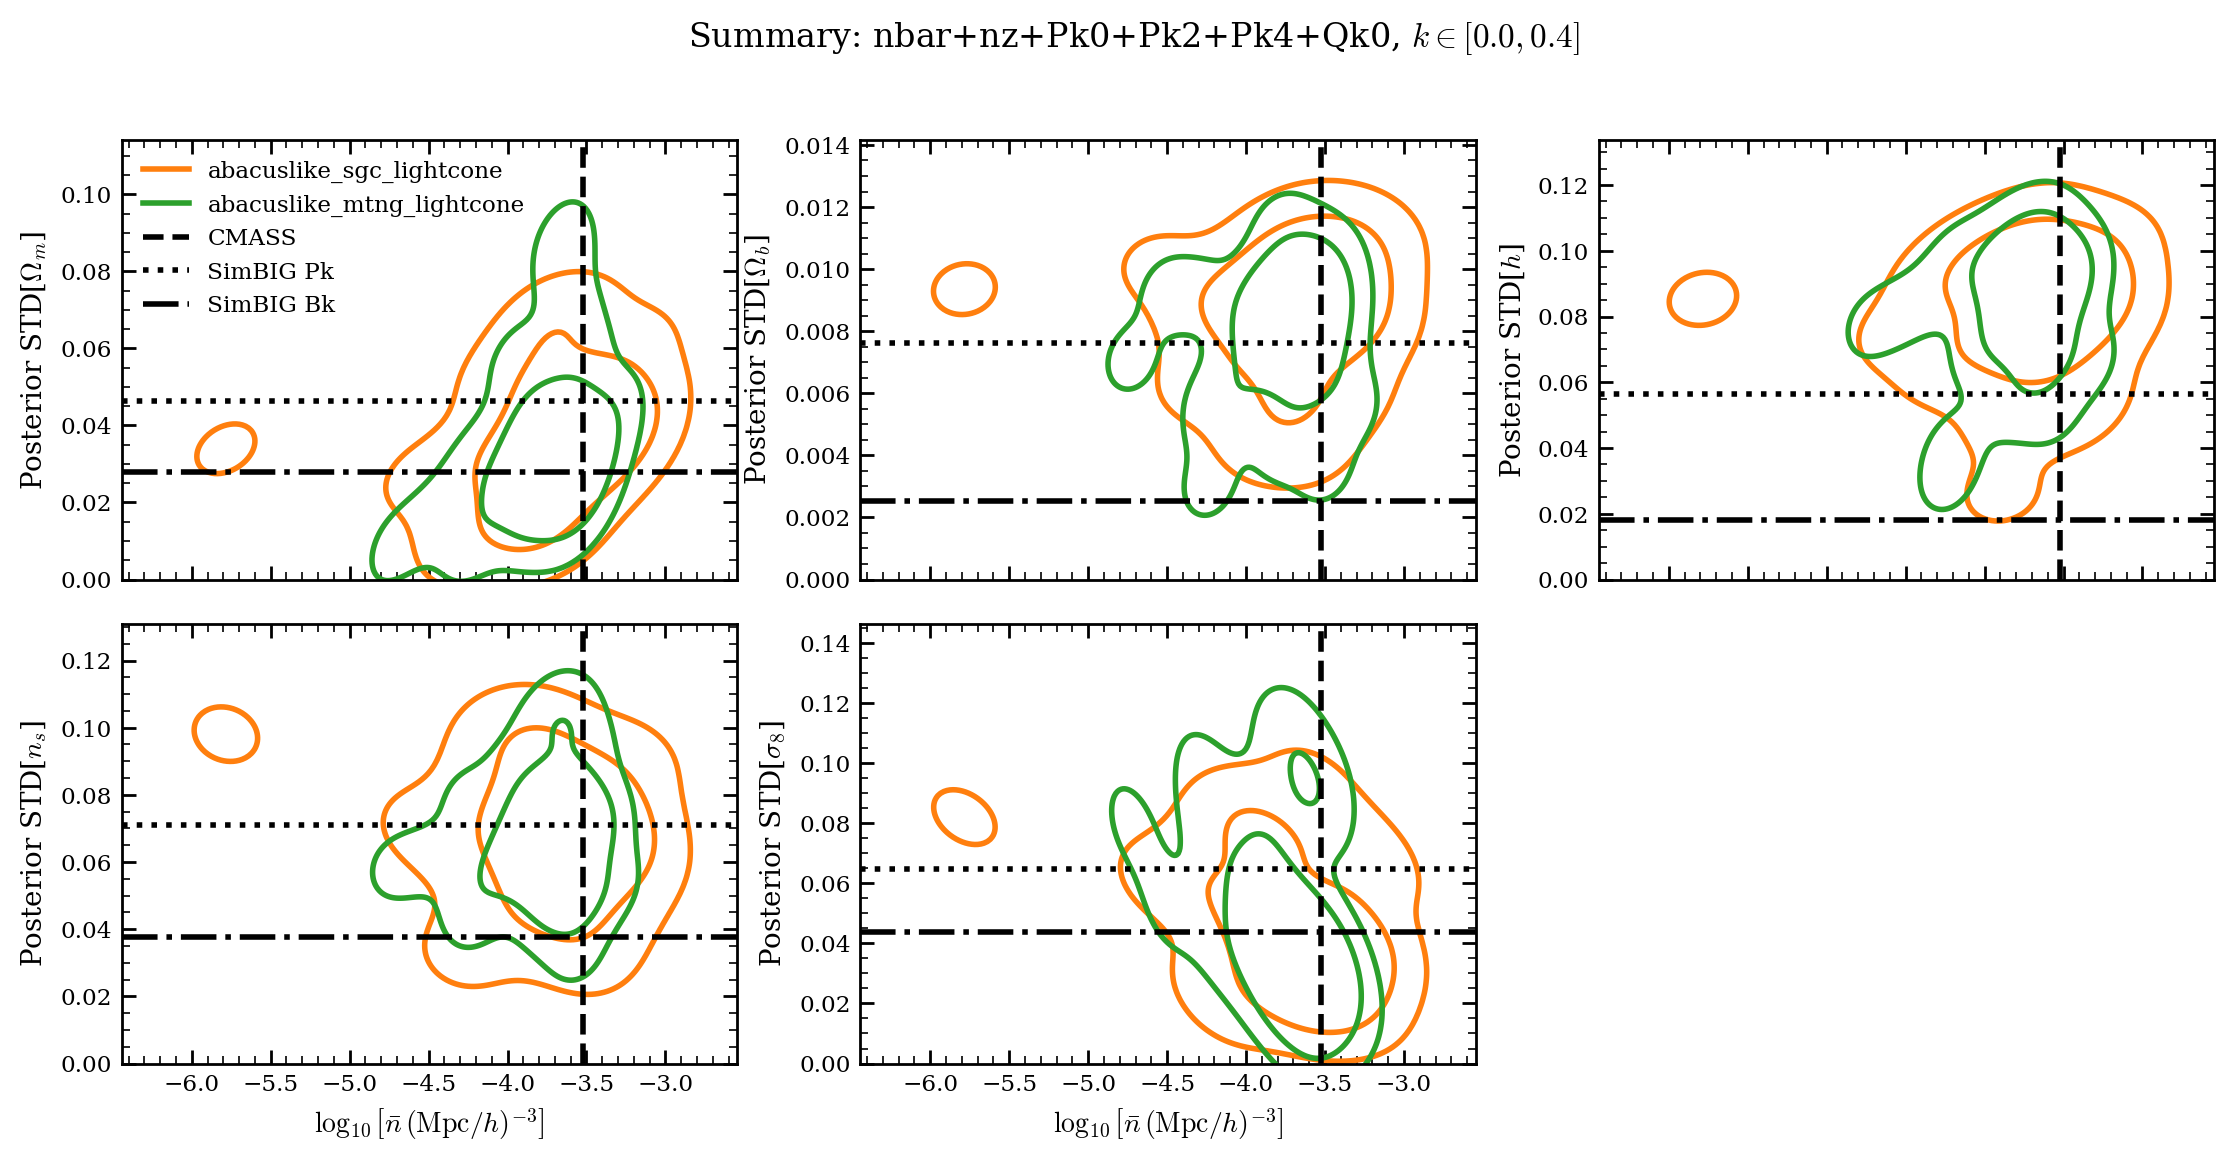

In [22]:

ss = 20

if 'nbar' not in summaries:
    raise ValueError('Cell only works for nbar summary')

summary = summarylist[-1]
xtests = xtestdict[summary]
sampss = sampsdict[summary]

nbar_CMASS = np.log10(3e-4)
sb_pkstd = np.std(simpk.values[:, :-1].astype(float), axis=0)
sb_bkstd = np.std(simbk.values[:, :-1].astype(float), axis=0)

W = 3
H = len(names) // W + (len(names) % W > 0)
f, axs = plt.subplots(H, W, figsize=(4.5*W, 3*H),
                      sharex=True,
                      gridspec_kw=dict(hspace=0.1))
axs = axs.flatten()

suite_colors = [f'C{i}' for i in range(len(suites))]

for i, ax in enumerate(axs):
    if i >= len(names):
        ax.axis('off')
        continue

    for j, t in enumerate(keys):
        if t not in xtests:
            continue

        xtest = xtests[t]
        samps = sampss[t]
        if 'galaxy' not in t:
            lognbar = xtest[:, -1] + np.log10(boxvols[j] / vols[j])
        else:
            lognbar = xtest[:, -1]
        std_dev = samps.std(axis=0)[:, i]

        # 2. Subsample the data
        lognbar_sub = lognbar[::ss]
        std_dev_sub = std_dev[::ss]

        # 3. Plot smooth contours
        sns.kdeplot(
            x=lognbar_sub,
            y=std_dev_sub,
            ax=ax,
            color=suite_colors[j],
            levels=[0.05, 0.32]
        )
        # Add a line for the legend
        ax.plot([], [], color=suite_colors[j], label=t)

    # Plot reference lines
    ax.axvline(nbar_CMASS, color='k', ls='--', label='CMASS')
    ax.axhline(sb_pkstd[i], color='k', ls=':', label='SimBIG Pk')
    ax.axhline(sb_bkstd[i], color='k', ls='-.', label='SimBIG Bk')

    ax.set_ylabel(f'Posterior STD[{names[i]}]')
    ax.set_ylim(bottom=0)
    if i >= len(names) - W:
        ax.set_xlabel(r'$\log_{10}\left[\bar{n}\, ({\rm Mpc}/h)^{-3}\right]$')
    if i == 0:
        ax.legend()

f.suptitle(f'Summary: {summary}, $k\in[{kmin},{kmax}]$')

plt.show()

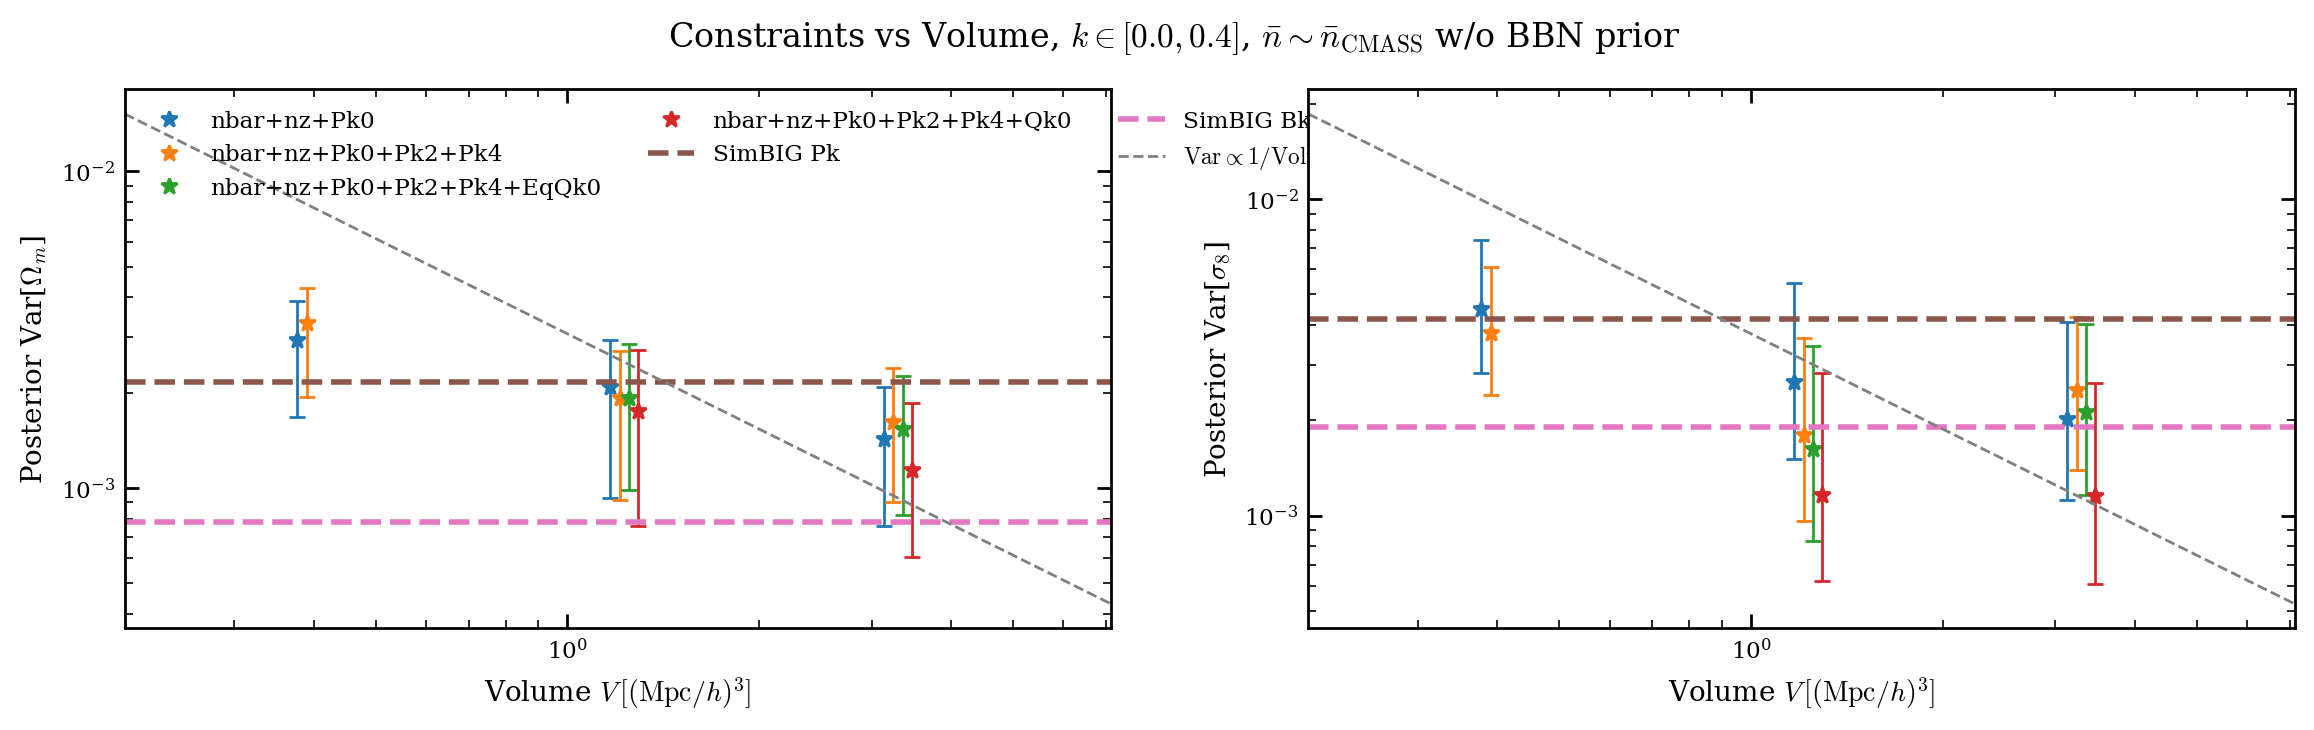

In [23]:
if 'nbar' not in summaries:
    raise ValueError('Cell only works for nbar summary')

# --- Helper function for weighted variance ---


def weighted_variance(values, weights, axis=None):
    """Computes the weighted variance along a given axis."""
    average = np.average(values, weights=weights, axis=axis)
    # Add new axis to broadcast `average` correctly for subtraction
    if axis is not None:
        average = np.expand_dims(average, axis=axis)
    variance = np.average((values - average)**2, weights=weights, axis=axis)
    return variance


# Constants
nbar_CMASS = np.log10(3e-4)
dnbar = 0.2
W, H = 2, 1

# Compute standard deviations
sb_pkstd = np.std(simpk.values[:, :-1].astype(float), axis=0)
sb_bkstd = np.std(simbk.values[:, :-1].astype(float), axis=0)

# Create subplots
f, axs = plt.subplots(H, W, figsize=(7 * W, 3.5 * H),
                      sharex=True, gridspec_kw=dict(hspace=0.1))
axs = axs.flatten()

# Iterate over parameters
for k, i in enumerate([0, 4]):  # Only plot Omega_m and sigma_8

    ax = axs[k]
    if i >= len(names):
        ax.axis('off')
        continue

    all_volumes = []
    all_variances = []

    # Iterate over summaries
    for l, summary in enumerate(summarylist):
        summary_labeled = False  # To ensure a summary is labeled only once
        # Plot data for each suite
        for j, t in enumerate(keys):
            # Check if data for this suite and summary exists before plotting
            if t not in xtestdict[summary]:
                continue

            xtest = xtestdict[summary][t]
            samps = sampsdict[summary][t]

            if 'galaxy' not in t:
                lognbar = xtest[:, -1] + np.log10(boxvols[j] / vols[j])
            else:
                lognbar = xtest[:, -1]
            mask = (lognbar > nbar_CMASS -
                    dnbar) & (lognbar < nbar_CMASS + dnbar)

            # Skip if no data points fall within the nbar mask
            if not np.any(mask):
                continue

            weights = None
            p = np.percentile(samps[:, mask, i].var(
                axis=0), [16, 50, 84], axis=0)

            # # --- MODIFICATION: Set a BBN Prior for n_s ---
            # # Define prior width for n_s
            # ns_prior_width = 0.0042
            # # Get samples for the parameter of interest (Omega_m or sigma_8)
            # param_samps = samps[:, mask, i]
            # # Get true n_s values (from ytestdict) and sampled n_s values
            # ns_true = ytestdict[summary][t][mask, 3]
            # ns_samps = samps[:, mask, 3]
            # # Calculate importance weights from the n_s prior
            # weights = np.exp(-0.5 * ((ns_samps - ns_true) / ns_prior_width)**2)
            # # Calculate the weighted variance for each posterior and get percentiles
            # w_var = weighted_variance(param_samps, weights=weights, axis=0)
            # p = np.percentile(w_var, [16, 50, 84], axis=0)
            # # --- END MODIFICATION ---

            # Plot median and error bars
            offset = (1 + l/30 - len(summarylist)/30/2)
            volume = vols[j] * offset
            variance = p[1]

            label = summary if not summary_labeled else None
            ax.plot(volume, variance,
                    '*' if 'nz' in summary else '.',
                    c=f'C{l}',
                    label=label)
            if label:
                summary_labeled = True

            yerr = np.array([[variance - p[0], p[2] - variance]]).T
            ax.errorbar(volume, variance, yerr=yerr, fmt='none',
                        ecolor=f'C{l}', elinewidth=1, capsize=3, capthick=1)

            # Append data for the fit
            all_volumes.append(volume)
            all_variances.append(variance)

    # Plot reference lines if data was plotted
    if not all_volumes:
        continue

    ax.axhline(sb_pkstd[i]**2, color='C5', ls='--', label='SimBIG Pk')
    ax.axhline(sb_bkstd[i]**2, color='C6', ls='--', label='SimBIG Bk')

    # Calculate the normalization factor from all points
    norm_factor = np.mean(np.array(all_variances) * np.array(all_volumes))
    _v = np.linspace(vols.min() / 2, vols.max() * 2, 100)
    ax.plot(_v, norm_factor / _v, '--', c='gray', lw=1,
            label=r'${\rm Var} \propto 1/{\rm Volume}$')

    # Set axis properties
    ax.loglog()
    ax.set_xlim(_v.min(), _v.max())
    # ax.set_ylim(8e-5, 2e-2)
    ax.set_ylabel(f'Posterior Var[{names[i]}]')
    ax.set_xlabel(r'Volume $V\,[({\rm Mpc}/h)^3]$')
    ax.grid

axs[0].legend(ncol=3)

# Set title
f.suptitle(f'Constraints vs Volume' +
           f', $k\\in[{kmin},{kmax}]$, ' + r'$\bar{n} \sim \bar{n}_{\rm CMASS}$' +
           (' w/o BBN prior' if weights is None else ' w/ BBN prior'))

plt.show()

## Measure survey volume

In [ ]:
import h5py
wdir = '/anvil/scratch/x-mho1/cmass-ili'
nbar_randoms = 3e-5


# SIMBIG
nbody = 'abacus'
sim = 'randoms'
L, N = 2000, 256
tracer = 'simbig_lightcone'
suitepath = join(wdir, nbody, sim, f'L{L}-N{N}')

simpath = join(suitepath, str(0))
filename = join(simpath, tracer, 'hod00000_aug00000.h5')
with h5py.File(filename, 'r') as f:
    Ngal = len(f['ra'][:])
volume = Ngal / nbar_randoms / (1e3)**3
print(f'{tracer} volume: {volume:.3f} (Gpc/h)^3')

# MTNG
nbody = 'abacus'
sim = 'randoms'
L, N = 2000, 256
tracer = 'mtng_lightcone'
suitepath = join(wdir, nbody, sim, f'L{L}-N{N}')

simpath = join(suitepath, str(0))
filename = join(simpath, tracer, 'hod00000_aug00000.h5')
with h5py.File(filename, 'r') as f:
    Ngal = len(f['ra'][:])
volume = Ngal / nbar_randoms / (1e3)**3
print(f'{tracer} volume: {volume:.3f} (Gpc/h)^3')

# SGC
nbody = 'abacus'
sim = 'randoms'
L, N = 2000, 256
tracer = 'sgc_lightcone'
suitepath = join(wdir, nbody, sim, f'L{L}-N{N}')

simpath = join(suitepath, str(0))
filename = join(simpath, tracer, 'hod00000_aug00000.h5')
with h5py.File(filename, 'r') as f:
    Ngal = len(f['ra'][:])
volume = Ngal / nbar_randoms / (1e3)**3
print(f'{tracer} volume: {volume:.3f} (Gpc/h)^3')

# NGC
nbody = 'quijote3gpch'
sim = 'randoms'
L, N = 3000, 384
tracer = 'ngc_lightcone'
suitepath = join(wdir, nbody, sim, f'L{L}-N{N}')

simpath = join(suitepath, str(0))
filename = join(simpath, tracer, 'hod00000_aug00000.h5')
with h5py.File(filename, 'r') as f:
    Ngal = len(f['ra'][:])
volume = Ngal / nbar_randoms / (1e3)**3
print(f'{tracer} volume: {volume:.3f} (Gpc/h)^3')

simbig_lightcone volume: 0.404 (Gpc/h)^3
mtng_lightcone volume: 3.358 (Gpc/h)^3
sgc_lightcone volume: 1.251 (Gpc/h)^3
ngc_lightcone volume: 3.562 (Gpc/h)^3


## Scratch

### Copy of old plot

In [ ]:
temp_df = pd.read_csv('tempsigma8.csv', skipinitialspace=True)
N = len(temp_df)

med = temp_df[::3]
low = temp_df[1::3]
high = temp_df[2::3]
med, low, high = map(np.sqrt, [med, low, high])

data = {}
names = ['pk0', 'pk024', 'eq0', 'q0']
names = [r'$P_0(k<0.4)$', r'$P_{\ell=0,2,4}(k<0.4)$', r'$P_\ell(k<0.4)+Q_0(k_{\rm eq}<0.4)$',
         r'$P_\ell(k<0.4)+Q_0(k<0.4)$']
# names = ['$P(k)$ monopole', '$P(k)$ all' ]
names = ['LtU ' + x for x in names]
names = np.array(names)
n = len(names)
vols = np.array([1, 2, 3])**3  # for boxes
for i, name in enumerate(names):
    data[name] = (
        med[i::4],
        low[i::4],
        high[i::4]
    )
names = names[[0, 1, 3]]

# Compute standard deviations
sb_pkstd = np.std(simpk.values[:, :-1].astype(float), axis=0)
sb_bkstd = np.std(simbk.values[:, :-1].astype(float), axis=0)

(0.01, 0.13)

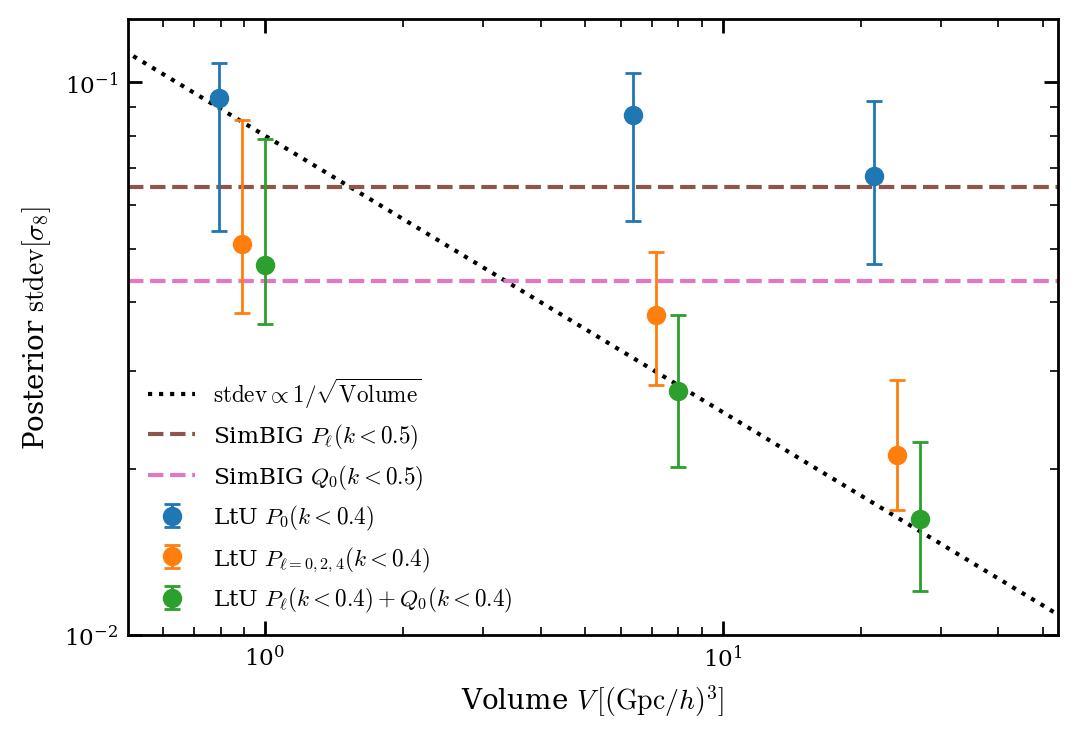

In [16]:
f, ax = plt.subplots(figsize=(6, 4))
ax.loglog()

_x = np.linspace(vols[0]*10**(-1), vols[-1]*10**(1), 100)
_y = (8e-2 / np.sqrt(_x))
ax.plot(_x, _y, 'k:', lw=1.5,
        label=r'${\rm stdev} \propto 1/\sqrt{\rm Volume}$')

ax.axhline(sb_pkstd[4], color='C5', ls='--',
           lw=1.5, label='SimBIG $P_\ell(k<0.5)$')
ax.axhline(sb_bkstd[4], color='C6', ls='--',
           lw=1.5, label='SimBIG $Q_0(k<0.5)$')

dv = 0.05
for i, name in enumerate(names):
    med, low, high = data[name]
    ax.errorbar(vols*10**(i*dv - n*dv/2),
                med['y'], yerr=[med['y'] - low['y'].values,
                                high['y'].values - med['y']],
                fmt='o', elinewidth=1, capsize=3, capthick=1,
                label=name)
ax.set_xlabel(r'Volume $V\,[({\rm Gpc}/h)^3]$')
ax.set_ylabel(r'Posterior ${\rm stdev}[\sigma_8]$')
ax.legend(ncol=1)
dv = 0.3
ax.set_xlim(vols[0]*10**(-dv), vols[-1]*10**(dv))
ax.set_ylim(1e-2, 1.3e-1)

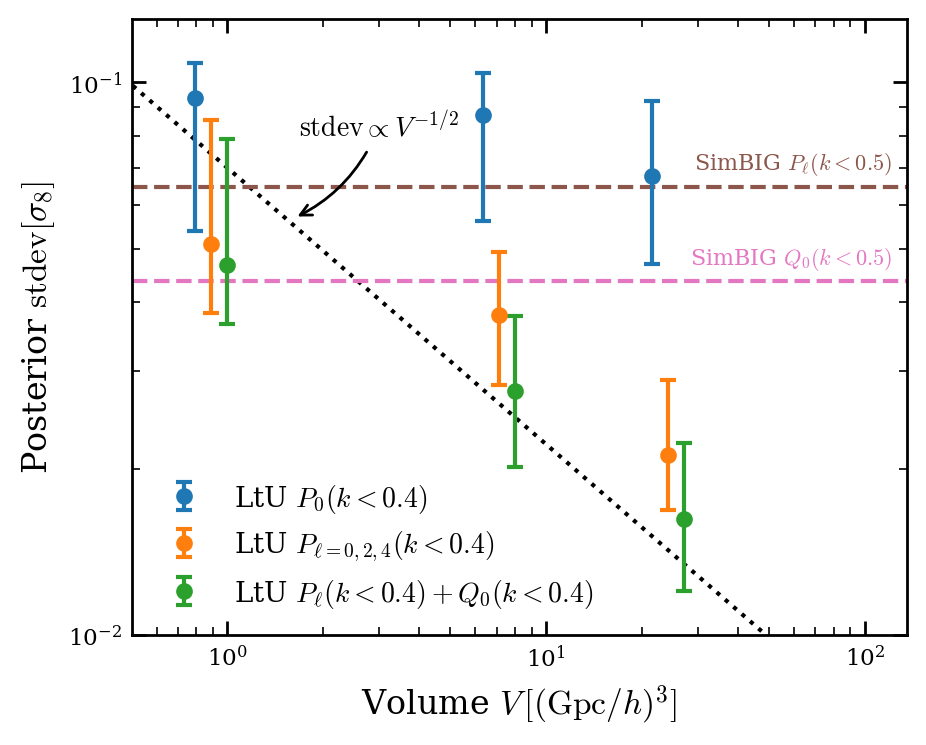

In [71]:
f, ax = plt.subplots(figsize=(5, 4))
ax.loglog()

_x = np.linspace(vols[0]*10**(-1), vols[-1]*10**(1), 100)
_y = (7e-2 / np.sqrt(_x))
# Plot lines without adding them to the legend
ax.plot(_x, _y, 'k:', lw=1.5, ls=':')
ax.axhline(sb_pkstd[4], color='C5', ls='--', lw=1.5)
ax.axhline(sb_bkstd[4], color='C6', ls='--', lw=1.5)


dv = 0.05
for i, name in enumerate(names):
    med, low, high = data[name]
    ax.errorbar(vols*10**(i*dv - n*dv/2),
                med['y'], yerr=[med['y'] - low['y'].values,
                                high['y'].values - med['y']],
                fmt='o', elinewidth=1.5, capsize=3, capthick=1.5, markersize=5,
                label=name, zorder=10)

ax.set_xlabel(r'Volume $V\,[({\rm Gpc}/h)^3]$', fontsize=12)
ax.set_ylabel(r'Posterior ${\rm stdev}[\sigma_8]$', fontsize=12)
dv = 0.4
ax.set_xlim(vols[0]*10**(-0.3), vols[-1]*10**(0.7))
ax.set_ylim(1e-2, 1.3e-1)

# --- Add labels directly onto the plot ---
p1 = ax.transData.transform_point((_x[20], _y[20]))
p2 = ax.transData.transform_point((_x[80], _y[80]))
angle = np.degrees(np.arctan2(p2[1] - p1[1], p2[0] - p1[0]))
ax.annotate(r'${\rm stdev} \propto V^{-1/2}$',  # Your text label
            # Point the arrow is pointing to (on the line)
            xy=(1.6, 8e-2 / np.sqrt(2)),
            xytext=(3., 0.08),                       # Where the text is located
            arrowprops=dict(arrowstyle="->",      # Arrow style
                            connectionstyle="arc3,rad=-0.2",  # Curve of the arrow
                            color='black'),
            ha='center')

xlim_max = ax.get_xlim()[1]*0.9  # Get the final x-limit for positioning
ax.text(xlim_max, sb_pkstd[4]*1.1, ' SimBIG $P_\ell(k<0.5)$', fontsize=8,
        color='C5', ha='right', va='center')
ax.text(xlim_max, sb_bkstd[4]*1.1, ' SimBIG $Q_0(k<0.5)$', fontsize=8,
        color='C6', ha='right', va='center')

# The legend will now correctly show only the labels from the errorbar plots
ax.legend(ncol=1, fontsize=10)
# ax.set_title(
#     r'$k_{\rm max} = 0.4\ h/{\rm Mpc}$, $\bar{n} \sim \bar{n}_{\rm CMASS}$',)

In [73]:
temp_df = pd.read_csv('tempOmegaM.csv', skipinitialspace=True)
N = len(temp_df)

med = temp_df[::3]
low = temp_df[1::3]
high = temp_df[2::3]
med, low, high = map(np.sqrt, [med, low, high])

data = {}
names = ['pk0', 'pk024', 'eq0', 'q0']
names = [r'$P_0(k<0.4)$', r'$P_{\ell=0,2,4}(k<0.4)$', r'$P_\ell(k<0.4)+Q_0(k_{\rm eq}<0.4)$',
         r'$P_\ell(k<0.4)+Q_0(k<0.4)$']
# names = ['$P(k)$ monopole', '$P(k)$ all' ]
names = ['LtU ' + x for x in names]
names = np.array(names)
n = len(names)
vols = np.array([1, 2, 3])**3  # for boxes
for i, name in enumerate(names):
    data[name] = (
        med[i::4],
        low[i::4],
        high[i::4]
    )
names = names[[0, 1, 3]]

# Compute standard deviations
sb_pkstd = np.std(simpk.values[:, :-1].astype(float), axis=0)
sb_bkstd = np.std(simbk.values[:, :-1].astype(float), axis=0)

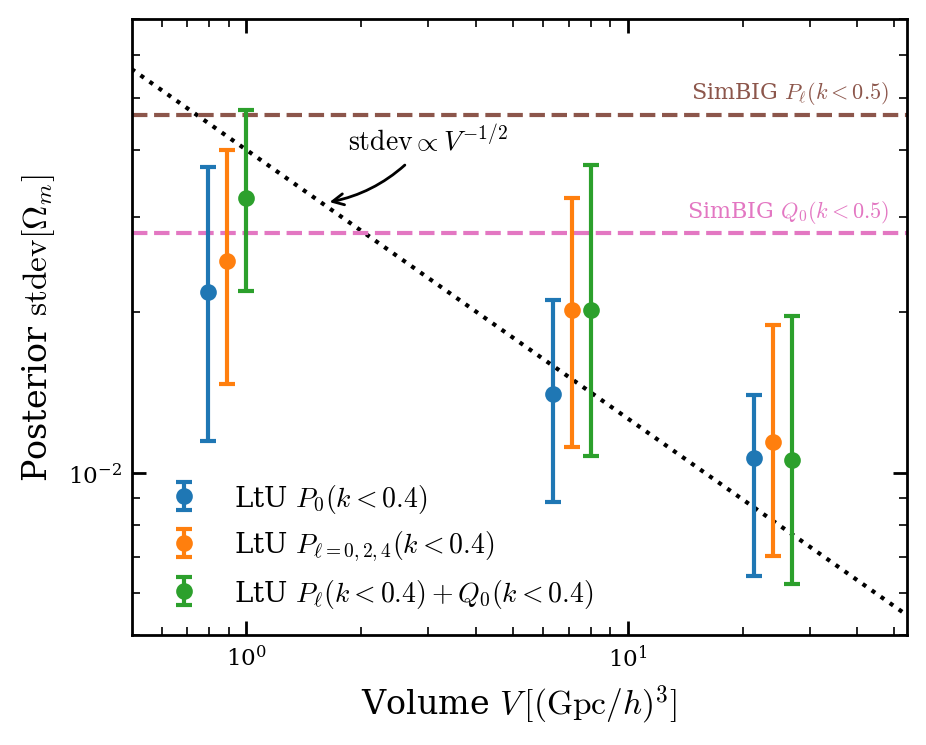

In [90]:
f, ax = plt.subplots(figsize=(5, 4))
ax.loglog()

_x = np.linspace(vols[0]*10**(-1), vols[-1]*10**(1), 100)
_y = (4e-2 / np.sqrt(_x))
# Plot lines without adding them to the legend
ax.plot(_x, _y, 'k:', lw=1.5, ls=':')
ax.axhline(sb_pkstd[0], color='C5', ls='--', lw=1.5)
ax.axhline(sb_bkstd[0], color='C6', ls='--', lw=1.5)


dv = 0.05
for i, name in enumerate(names):
    med, low, high = data[name]
    ax.errorbar(vols*10**(i*dv - n*dv/2),
                med['y'], yerr=[med['y'] - low['y'].values,
                                high['y'].values - med['y']],
                fmt='o', elinewidth=1.5, capsize=3, capthick=1.5, markersize=5,
                label=name, zorder=10)

ax.set_xlabel(r'Volume $V\,[({\rm Gpc}/h)^3]$', fontsize=12)
ax.set_ylabel(r'Posterior ${\rm stdev}[\Omega_m]$', fontsize=12)
dv = 0.4
ax.set_xlim(vols[0]*10**(-0.3), vols[-1]*10**(0.3))
ax.set_ylim(5e-3, 7e-2)

# --- Add labels directly onto the plot ---
p1 = ax.transData.transform_point((_x[20], _y[20]))
p2 = ax.transData.transform_point((_x[80], _y[80]))
angle = np.degrees(np.arctan2(p2[1] - p1[1], p2[0] - p1[0]))
ax.annotate(r'${\rm stdev} \propto V^{-1/2}$',  # Your text label
            # Point the arrow is pointing to (on the line)
            xy=(1.6, 4.5e-2 / np.sqrt(2)),
            xytext=(3., 0.04),                       # Where the text is located
            arrowprops=dict(arrowstyle="->",      # Arrow style
                            connectionstyle="arc3,rad=-0.2",  # Curve of the arrow
                            color='black'),
            ha='center')

xlim_max = ax.get_xlim()[1]*0.9  # Get the final x-limit for positioning
ax.text(xlim_max, sb_pkstd[0]*1.1, ' SimBIG $P_\ell(k<0.5)$', fontsize=8,
        color='C5', ha='right', va='center')
ax.text(xlim_max, sb_bkstd[0]*1.1, ' SimBIG $Q_0(k<0.5)$', fontsize=8,
        color='C6', ha='right', va='center')

# The legend will now correctly show only the labels from the errorbar plots
ax.legend(ncol=1, fontsize=10)
# ax.set_title(
#     r'$k_{\rm max} = 0.4\ h/{\rm Mpc}$, $\bar{n} \sim \bar{n}_{\rm CMASS}$',)

### Find good n(z)

In [ ]:
nz_obs = np.loadtxt(
    '/anvil/scratch/x-mho1/cmass-ili/obs/n-z/nz_DR12v5_CMASS_North_zmin0.4000_zmax0.7000.dat')
nz_obs_bin = np.linspace(0.4, 0.7, len(nz_obs)+1)
nz_obs_cen = 0.5*(nz_obs_bin[1:] + nz_obs_bin[:-1])

(0.0, 20000.0)

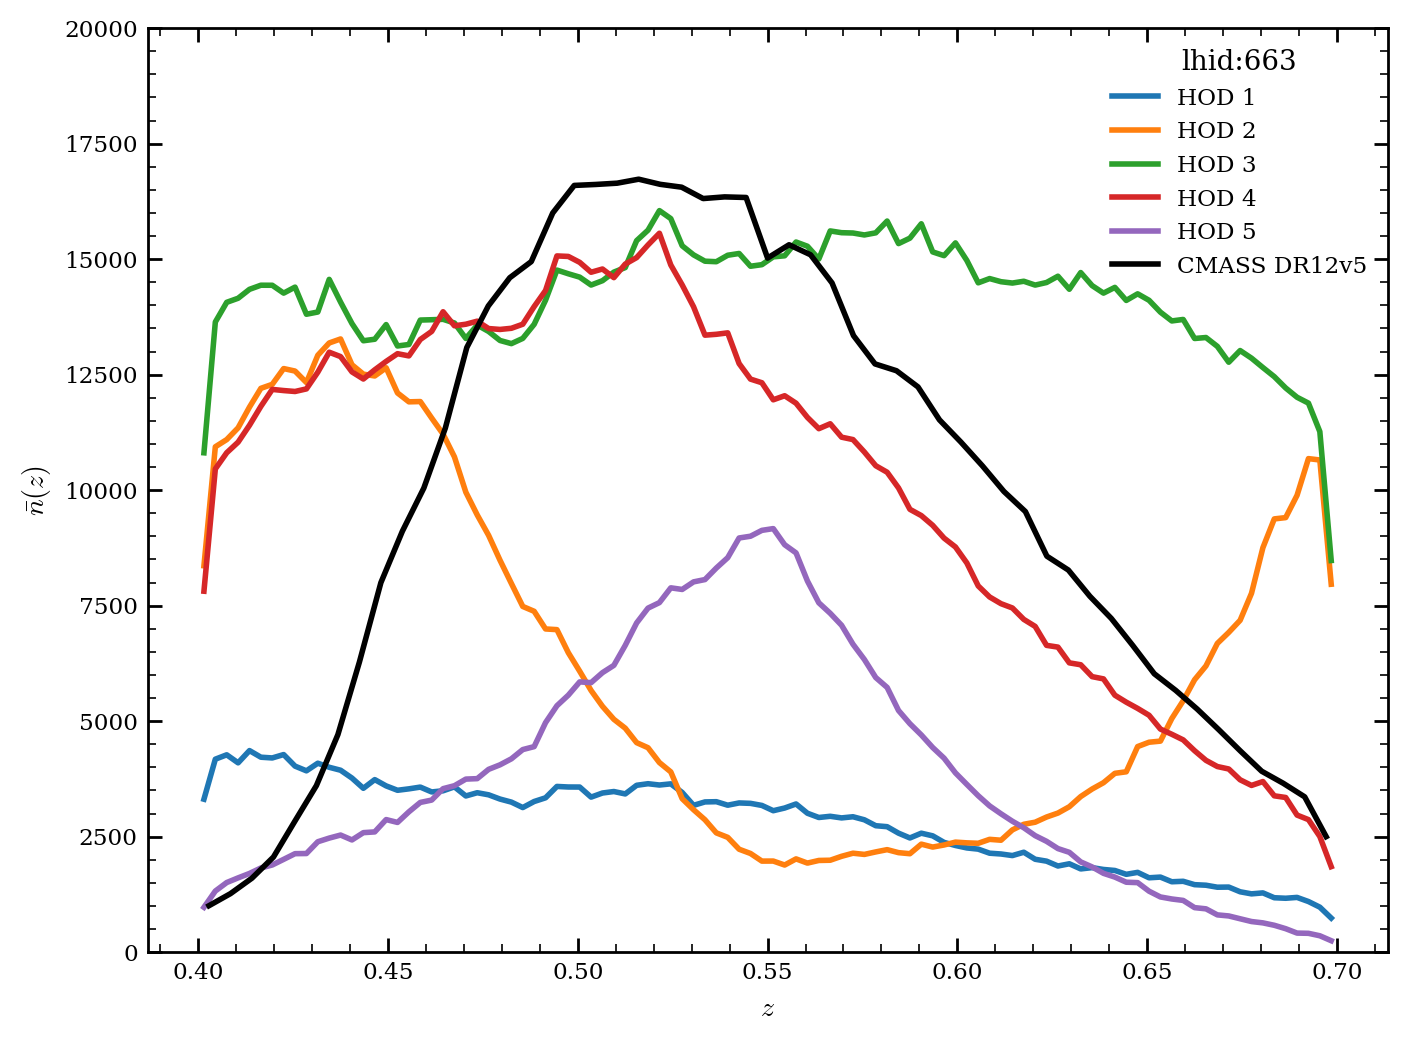

In [23]:
import h5py
plt.figure(figsize=(8, 6))

for i in range(1, 6):
    file_path = f'/anvil/scratch/x-mho1/cmass-ili/mtnglike/fastpm_recnoise/L3000-N384/663/diag/ngc_lightcone/hod0663{i}_aug00000.h5'

    with h5py.File(file_path, 'r') as f:
        nz = f['nz'][:]
        be = f['nz_bins'][:]

    bc = 0.5 * (be[:-1] + be[1:])
    plt.plot(bc, nz, '-', lw=2, label=f'HOD {i}')
plt.plot(nz_obs_cen, nz_obs, 'k-', lw=2, label='CMASS DR12v5')
plt.xlabel(r'$z$')
plt.ylabel(r'$\bar{n}(z)$')
plt.legend(title='lhid:663')
plt.ylim(0, 20000)

### Measure nbar

In [62]:
mcfgs

[{'batch_size': 32,
  'fcn_depth': 2,
  'fcn_width': 16,
  'hidden_features': 113,
  'learning_rate': 0.008286948265427594,
  'lr_decay_factor': 0.11723045897671178,
  'lr_patience': 19,
  'model': 'nsf',
  'num_transforms': 6,
  'weight_decay': 0.038685098176350116},
 {'batch_size': 32,
  'fcn_depth': 2,
  'fcn_width': 16,
  'hidden_features': 119,
  'learning_rate': 0.008549143384594914,
  'lr_decay_factor': 0.10649604129527843,
  'lr_patience': 19,
  'model': 'nsf',
  'num_transforms': 6,
  'weight_decay': 0.07885143083402874},
 {'batch_size': 32,
  'fcn_depth': 2,
  'fcn_width': 16,
  'hidden_features': 114,
  'learning_rate': 0.008355227252611005,
  'lr_decay_factor': 0.12084627820513541,
  'lr_patience': 19,
  'model': 'nsf',
  'num_transforms': 6,
  'weight_decay': 0.0959322772804557},
 {'batch_size': 32,
  'fcn_depth': 2,
  'fcn_width': 17,
  'hidden_features': 113,
  'learning_rate': 0.008028669231150788,
  'lr_decay_factor': 0.2750021091671599,
  'lr_patience': 19,
  'model':

In [91]:
hp = 'log2_batch_size'
np.log10(2**hyperprior[hp][0]), np.log10(2**hyperprior[hp][1])

(1.505149978319906, 2.709269960975831)

### Compare hyperparams

Text(0.5, 0.98, 'galaxy nbar+zPk0+zPk2+zPk4')

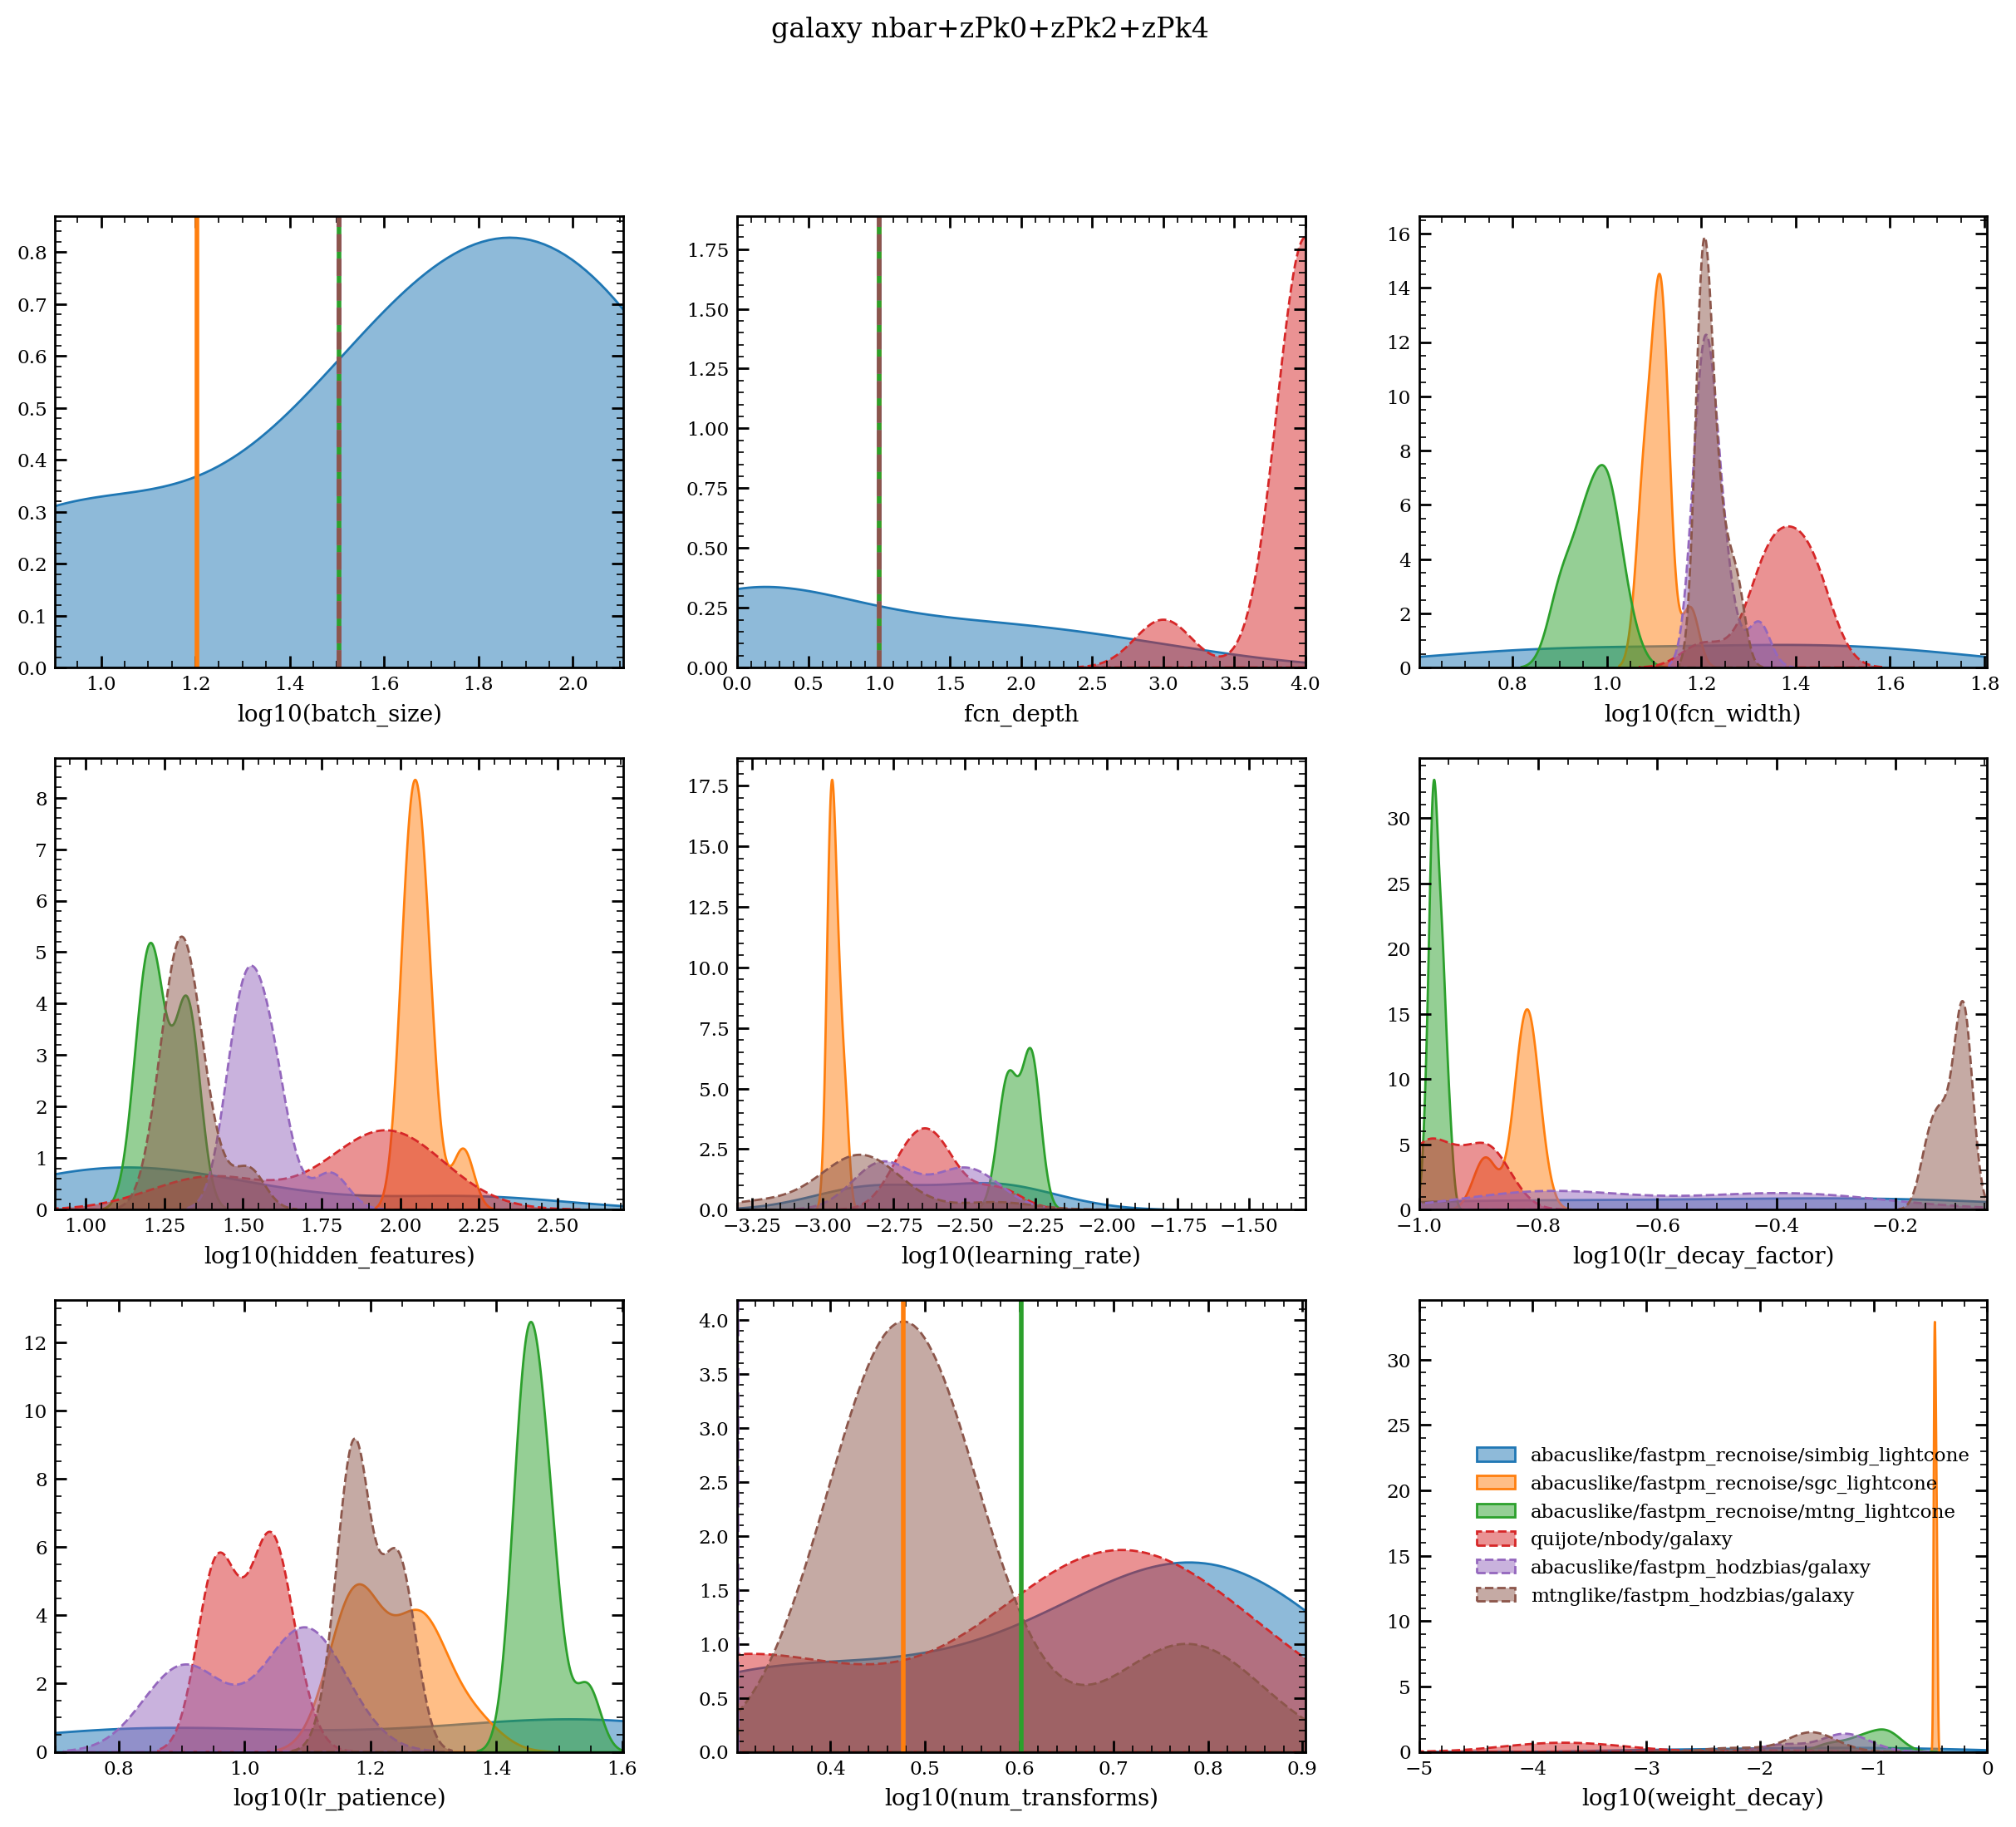

In [19]:
import yaml

H = 3
W = 3
fig, axs = plt.subplots(H, W, figsize=(5*W, 4*H))

hyperprior_file = '/home/x-mho1/git/ltu-cmass-run/cmass/conf/infer/lightcone.yaml'
with open(hyperprior_file, 'r') as f:
    hyperprior = yaml.safe_load(f)['hyperprior']

modeldirs = [
    '/anvil/scratch/x-mho1/cmass-ili/abacuslike/fastpm_recnoise/models/simbig_lightcone/nbar+nz+Pk0+Pk2+Pk4/kmin-0.0_kmax-0.4',
    '/anvil/scratch/x-mho1/cmass-ili/abacuslike/fastpm_recnoise/models/sgc_lightcone/nbar+nz+Pk0+Pk2+Pk4/kmin-0.0_kmax-0.4',
    '/anvil/scratch/x-mho1/cmass-ili/abacuslike/fastpm_recnoise/models/mtng_lightcone/nbar+nz+Pk0+Pk2+Pk4/kmin-0.0_kmax-0.4',
    '/anvil/scratch/x-mho1/cmass-ili/quijote/nbody/models/galaxy/nbar+zPk0+zPk2+zPk4/kmin-0.0_kmax-0.4',
    '/anvil/scratch/x-mho1/cmass-ili/abacuslike/fastpm_hodzbias/models/galaxy/nbar+zPk0+zPk2+zPk4/kmin-0.0_kmax-0.4',
    '/anvil/scratch/x-mho1/cmass-ili/mtnglike/fastpm_hodzbias/models/galaxy/nbar+zPk0+zPk2+zPk4/kmin-0.0_kmax-0.4'
]

for k, modelpath in enumerate(modeldirs):
    net_dir = join(modelpath, 'nets')
    mcfgs, log_probs = [], []
    for n in os.listdir(net_dir):
        model_config_path = join(net_dir, n, 'model_config.yaml')
        with open(model_config_path, 'r') as f:
            model_config = yaml.safe_load(f)
        mcfgs.append(model_config)

        log_prob_file = join(net_dir, n, 'log_prob_test.txt')
        if os.path.exists(log_prob_file):
            with open(log_prob_file, 'r') as f:
                log_prob = float(f.read().strip())
            log_probs.append(log_prob)

    hyperparams = list(model_config.keys())
    hyperparams.remove('model')

    axs = axs.flatten()
    for i, hp in enumerate(hyperparams):
        ax = axs[i]
        if i >= len(hyperparams):
            ax.axis('off')
            continue
        x_vals = [m[hp] for m in mcfgs]
        y_vals = log_probs

        if hp != 'fcn_depth':
            x_vals = np.log10(x_vals)

        # 1. 2D ERRORBAR PLOT
        # xs = np.percentile(x_vals, [50, 0, 100])
        # ys = np.percentile(y_vals, [50, 0, 100])
        # xerr = np.array([xs[0]-xs[1], xs[2]-xs[0]]).reshape(2, 1)
        # yerr = np.array([ys[0]-ys[1], ys[2]-ys[0]]).reshape(2, 1)
        # ax.errorbar(xs[0], ys[0], xerr=xerr, yerr=yerr, fmt='o', capsize=5)
        # ax.set_xlabel(hp)
        # ax.set_ylabel('Log Probability')
        # ax.set_title(f'Log Prob vs {hp}')

        # 2. Histogram
        name = '/'.join(np.array(modelpath.split('/'))[[5, 6, 8]])

        color = f'C{k}'
        linestyle = '--' if 'galaxy' in name else '-'

        if len(set(x_vals)) == 1:
            ax.axvline(x_vals[0], linestyle=linestyle, c=color, label=name)
        else:
            sns.kdeplot(x=x_vals, ax=ax, fill=True,
                        alpha=0.5, color=color, label=name, linestyle=linestyle)
        ax.set_xlabel(f'log10({hp})')
        ax.set_ylabel('')
        if 'batch_size' in hp:
            hp = 'log2_batch_size'
            ax.set_xlim(
                np.log10(2**hyperprior[hp][0]), np.log10(2**hyperprior[hp][1]))
        elif hp == 'fcn_depth':
            ax.set_xlim(hyperprior[hp][0], hyperprior[hp][1])
            ax.set_xlabel(f'{hp}')
        else:
            ax.set_xlim(np.log10(float(hyperprior[hp][0])),
                        np.log10(float(hyperprior[hp][1])))
axs[-1].legend()
fig.suptitle(modelpath.split('/')[-3] + ' ' + modelpath.split('/')[-2])

In [81]:
x_vals

array([-1.53311182, -1.63502948, -1.57031395, -1.33991463, -1.57970879,
       -1.62265822, -1.43355439, -2.3623611 , -2.05229239, -1.56577593])

In [28]:
x_vals

[0.038685098176350116,
 0.07885143083402874,
 0.0959322772804557,
 0.09097995916468893,
 0.09792087146030126,
 0.08647976699500831,
 0.09666038557798151,
 0.07385140505845858,
 0.05436328615086871,
 0.08146777508398628]

### Compare data vectors

Text(0.5, 0.98, 'nbar+zPk0')

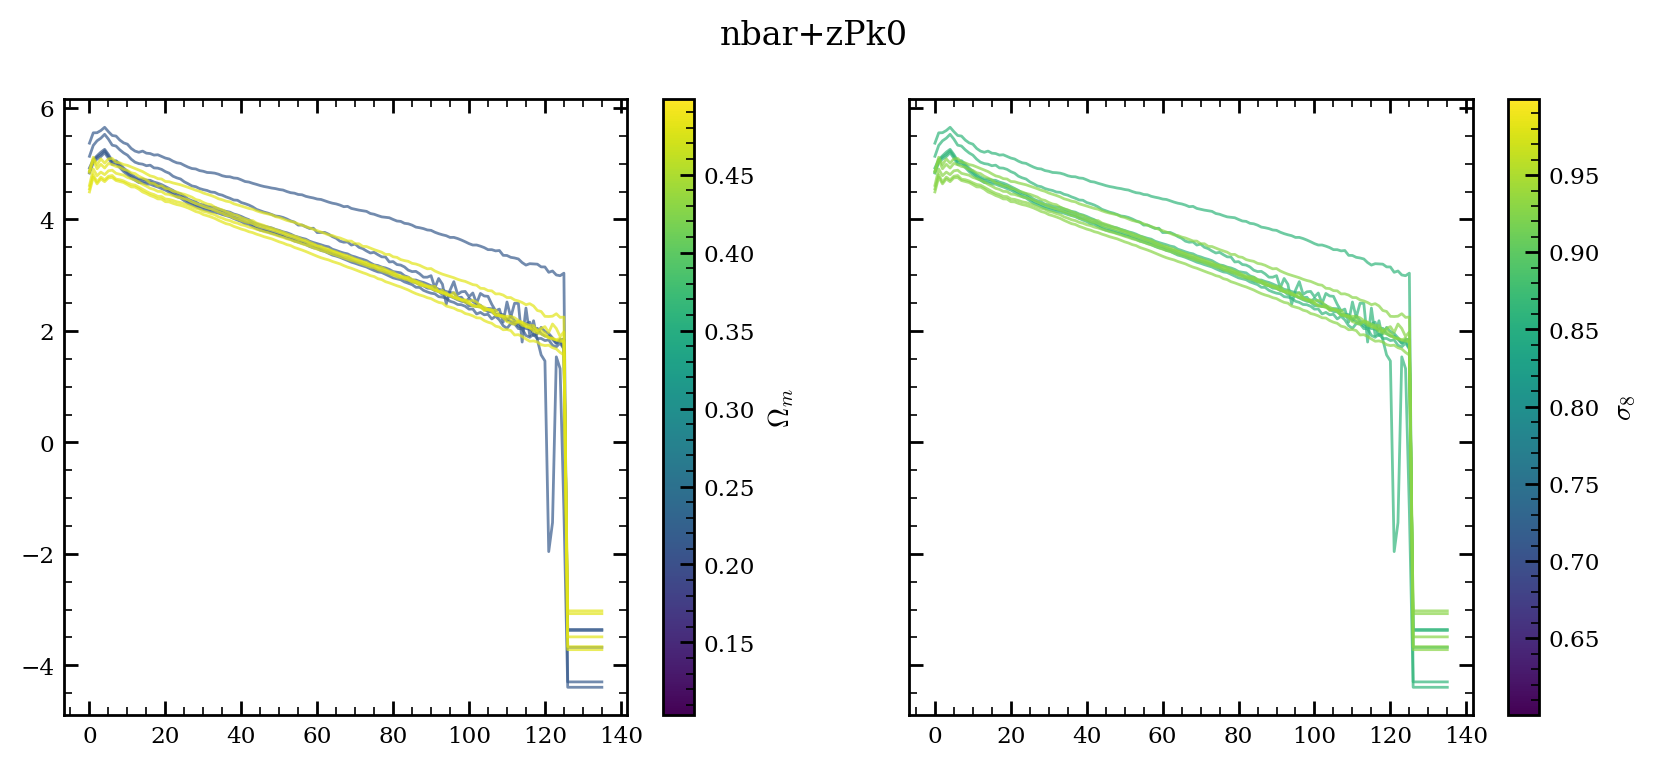

In [ ]:
modeldir = '/anvil/scratch/x-mho1/cmass-ili/abacuslike/fastpm_hodzbias/models/galaxy/nbar+zPk0/kmin-0.0_kmax-0.4'
xtest = np.load(join(modeldir, 'x_test.npy'))
thetatest = np.load(join(modeldir, 'theta_test.npy'))

N = 10
f, axs = plt.subplots(1, 2, figsize=(10, 4), sharey=True)

ax = axs[0]

k = 0
norm = mpl.colors.Normalize(
    vmin=thetatest[:, k].min(), vmax=thetatest[:, k].max())
for i in range(N):
    ax.plot(xtest[i], color=plt.cm.viridis(
        norm(thetatest[i, k])), lw=1, alpha=0.7)
f.colorbar(plt.cm.ScalarMappable(norm=norm, cmap='viridis'),
           label=r'$\Omega_m$', ax=ax)

ax = axs[1]
k = 4
norm = mpl.colors.Normalize(
    vmin=thetatest[:, k].min(), vmax=thetatest[:, k].max())
for i in range(N):
    ax.plot(xtest[i], color=plt.cm.viridis(
        norm(thetatest[i, k])), lw=1, alpha=0.7)
f.colorbar(plt.cm.ScalarMappable(norm=norm, cmap='viridis'),
           label=r'$\sigma_8$', ax=ax)

f.suptitle(modeldir.split('/')[-2])

In [62]:
xtrain = np.load(join(modeldir, 'x_train.npy'))
thetatrain = np.load(join(modeldir, 'theta_train.npy'))
print(xtrain.shape, thetatrain.shape)

(7917, 136) (7917, 5)


In [ ]:
import xgboost as xgb
import shap
import numpy as np
import pandas as pd
from sklearn.multioutput import MultiOutputRegressor
import matplotlib.pyplot as plt

# --- 1. Load or Generate Your Data ---
# For demonstration purposes, we'll generate random data with the shapes you provided.
# In your actual use case, you would load your xtrain and thetatrain here.
print("Generating sample data...")
num_samples = 7914
num_features = xtrain.shape[1]  # Assuming xtrain is already defined
num_targets = 5

# Replace these lines with your actual data loading
xtrain_np = xtrain  # np.random.rand(num_samples, num_features)
thetatrain_np = thetatrain  # np.random.rand(num_samples, num_targets)

# It's good practice to use DataFrames, as they allow for feature names.
feature_names = [f'feature_{i}' for i in range(num_features)]
target_names = [f'target_{i}' for i in range(num_targets)]

xtrain = pd.DataFrame(xtrain_np, columns=feature_names)
thetatrain = pd.DataFrame(thetatrain_np, columns=target_names)

print(f"xtrain shape: {xtrain.shape}")
print(f"thetatrain shape: {thetatrain.shape}")
print("-" * 30)


# --- 2. Define and Train the XGBoost Model ---
# We need to predict 5 target variables. We'll use scikit-learn's
# MultiOutputRegressor, which wraps an XGBoost model and trains one
# independent model for each target variable.

print("Training Multi-Output XGBoost model...")
# Define the base XGBoost regressor
# You can tune these hyperparameters for better performance
xgb_regressor = xgb.XGBRegressor(
    objective='reg:squarederror',
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1  # Use all available CPU cores
)

# Wrap the XGBoost model with MultiOutputRegressor
multi_output_model = MultiOutputRegressor(estimator=xgb_regressor)

# Train the model
multi_output_model.fit(xtrain, thetatrain)
print("Model training complete.")
print("-" * 30)

Generating sample data...
xtrain shape: (7917, 136)
thetatrain shape: (7917, 5)
------------------------------
Training Multi-Output XGBoost model...
Model training complete.
------------------------------


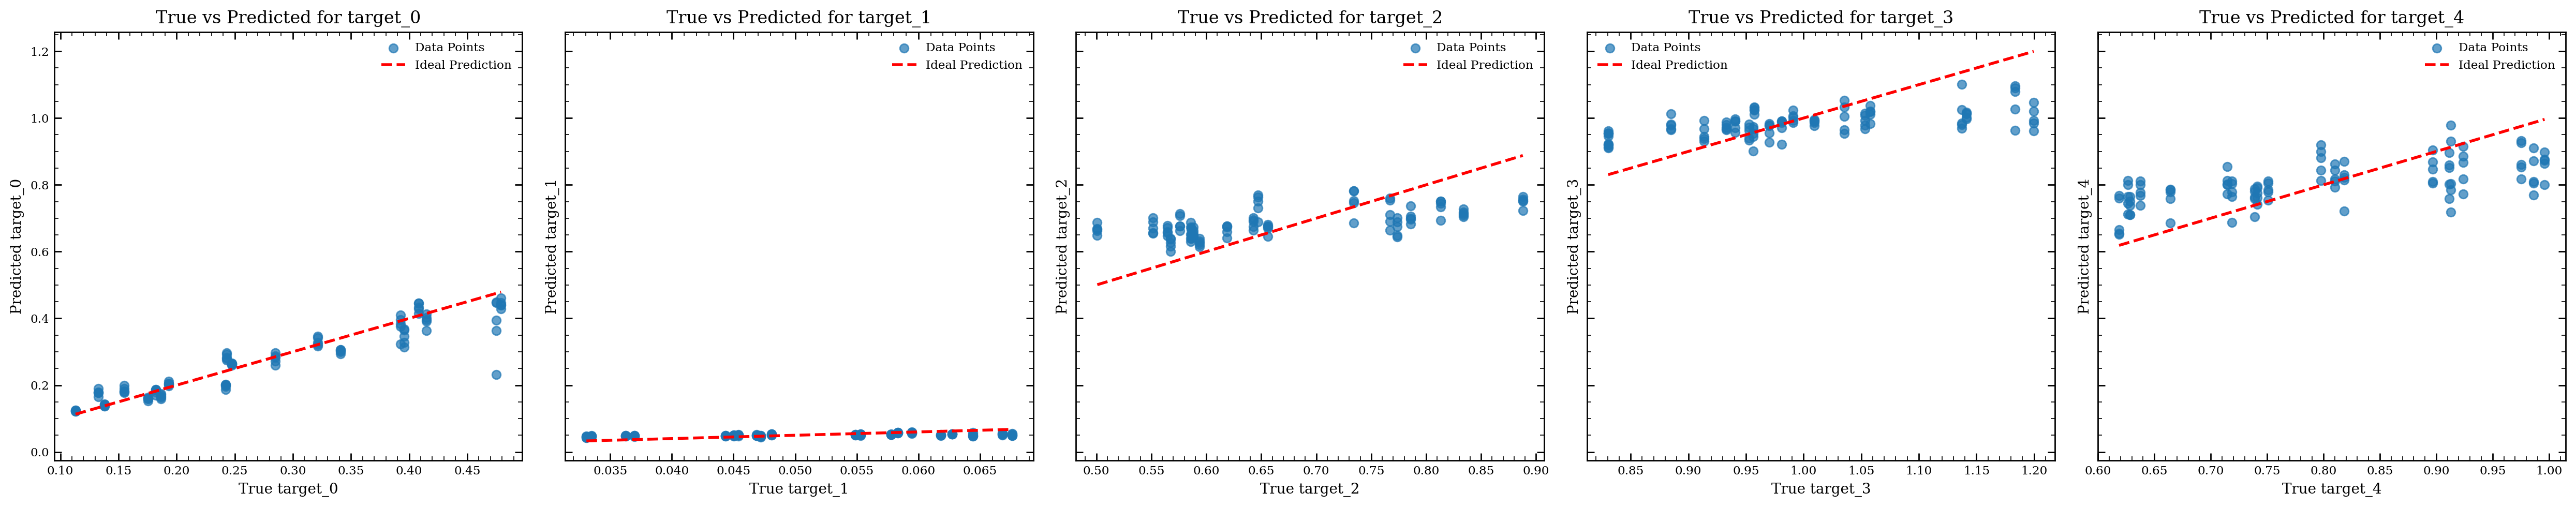

In [ ]:
# Select a subset of the data for visualization
subset_size = 100
xtrain_subset = xtrain.iloc[:subset_size]
thetatrain_subset = thetatrain.iloc[:subset_size]

# Predict using the trained model
predicted_values = multi_output_model.predict(xtrain_subset)

# Plot true vs predicted values for each target
num_targets = thetatrain.shape[1]
fig, axs = plt.subplots(1, num_targets, figsize=(
    5 * num_targets, 5), sharey=True)

for i, ax in enumerate(axs):
    ax.scatter(
        thetatrain_subset.iloc[:, i], predicted_values[:, i], alpha=0.7, label='Data Points')
    ax.plot([thetatrain_subset.iloc[:, i].min(), thetatrain_subset.iloc[:, i].max()],
            [thetatrain_subset.iloc[:, i].min(), thetatrain_subset.iloc[:, i].max()],
            'r--', label='Ideal Prediction')
    ax.set_xlabel(f'True {target_names[i]}')
    ax.set_ylabel(f'Predicted {target_names[i]}')
    ax.legend()
    ax.set_title(f'True vs Predicted for {target_names[i]}')

plt.tight_layout()
plt.show()

 98%|===================| 7768/7917 [00:11<00:00]       

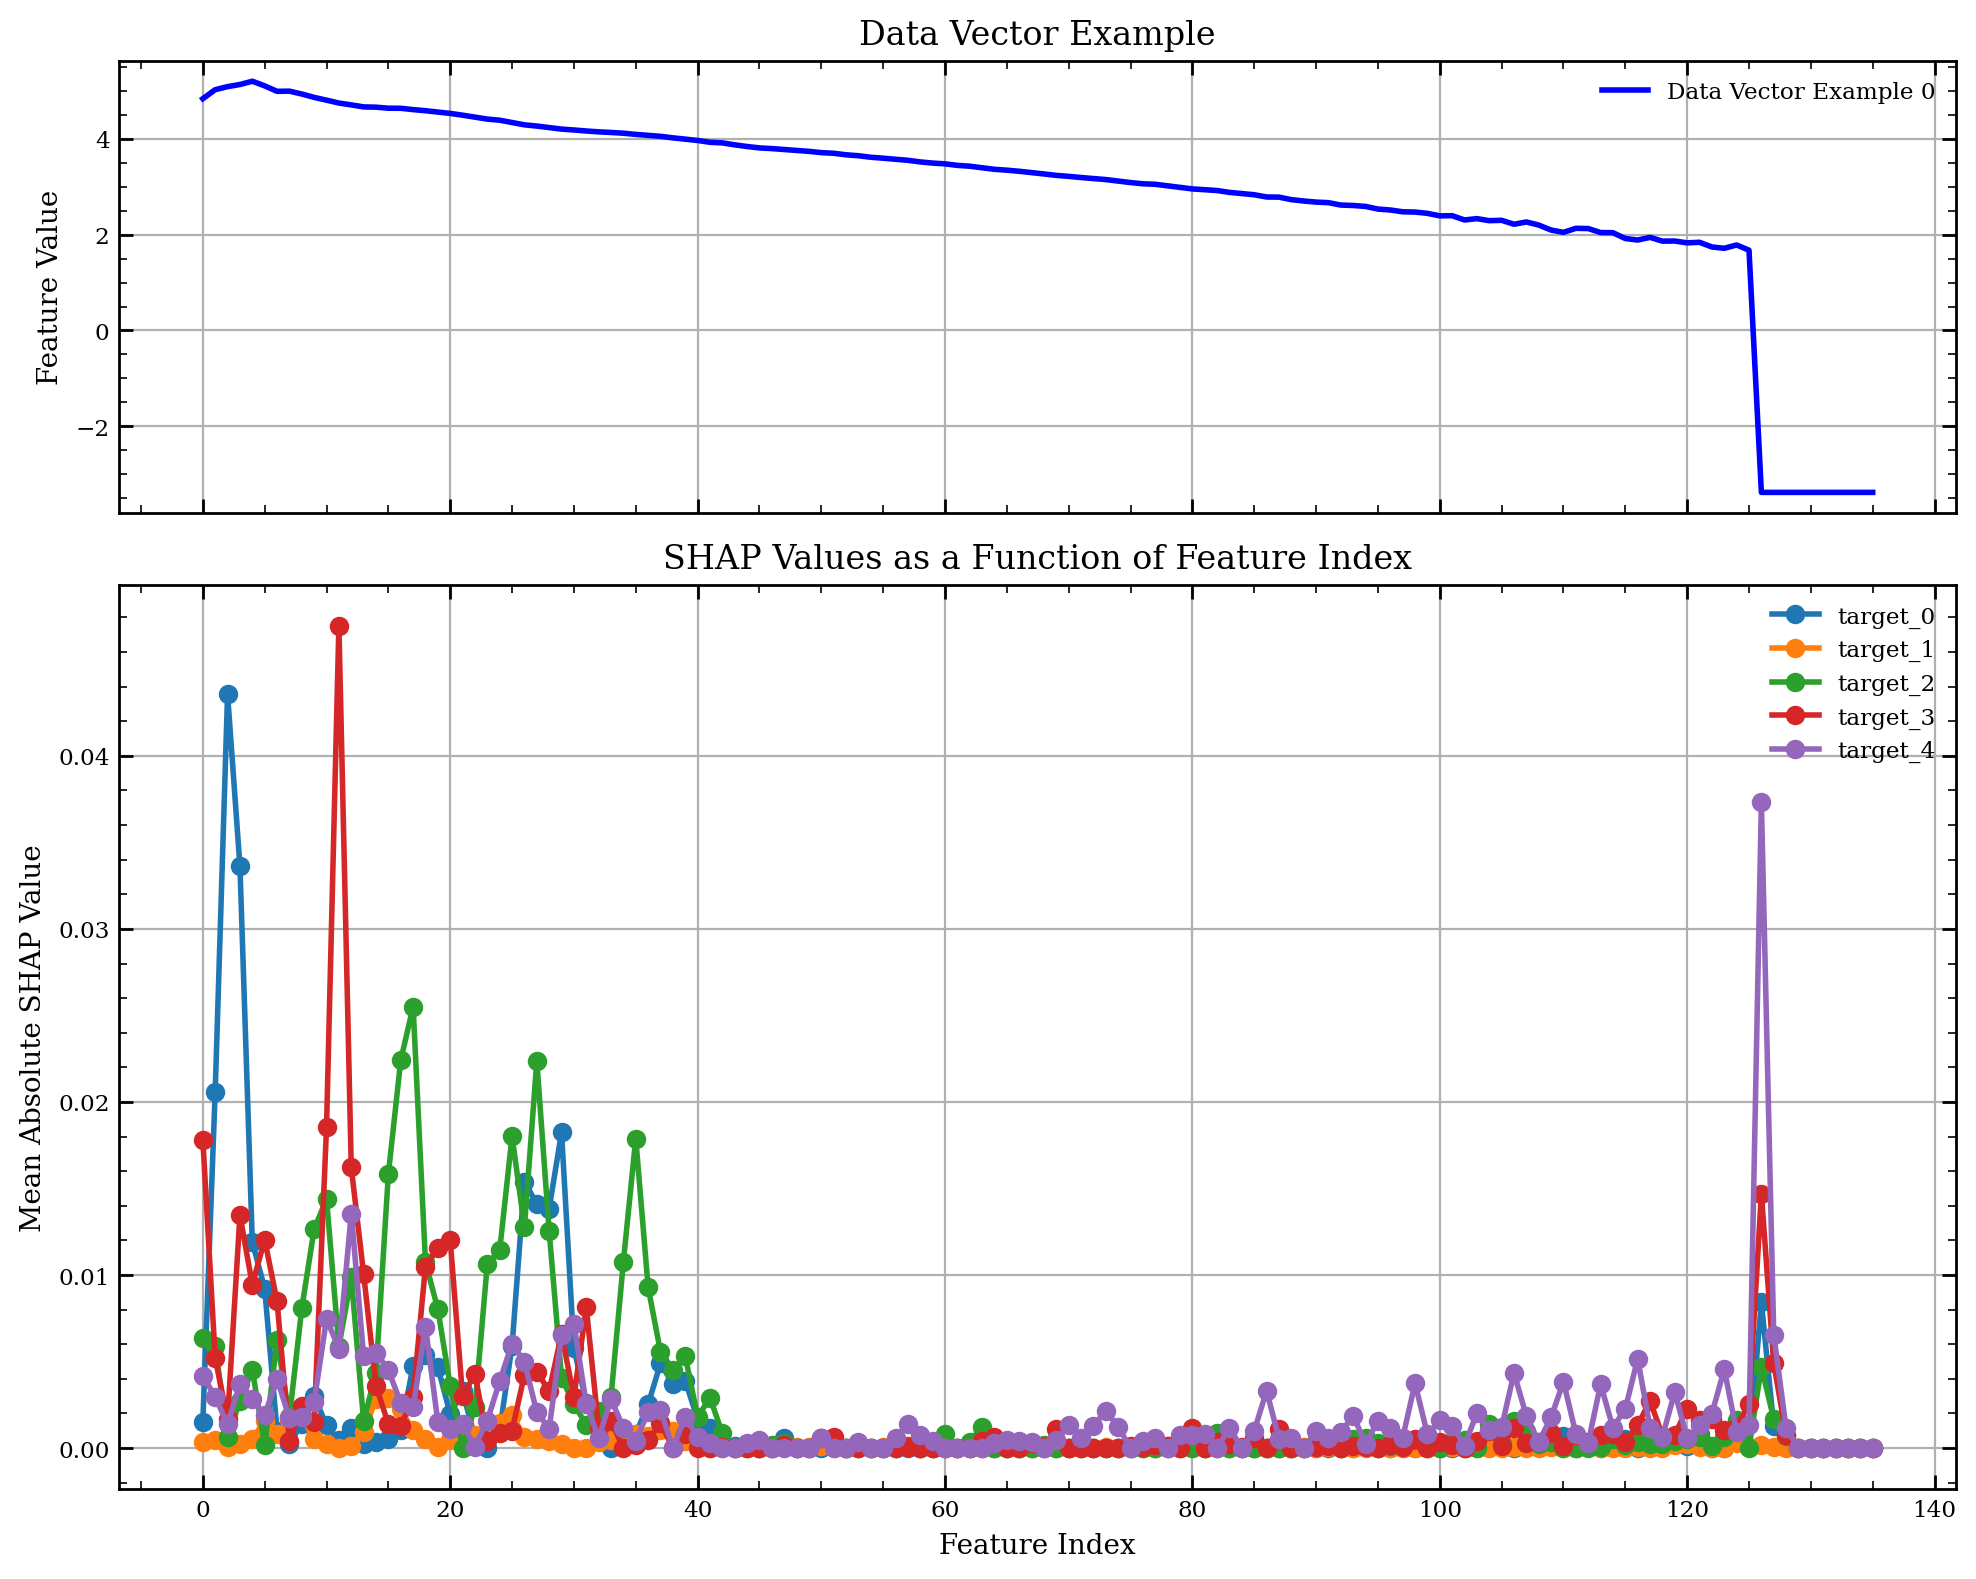

In [ ]:
fig, axs = plt.subplots(2, 1, figsize=(10, 8), sharex=True,
                        gridspec_kw={'height_ratios': [1, 2]})

# Top subplot: Data vector example
ax = axs[0]
example_index = 0  # Select an example index
ax.plot(range(xtest.shape[1]), xtest[example_index],
        label=f'Data Vector Example {example_index}', color='blue')
ax.set_ylabel('Feature Value')
ax.legend()
ax.grid()
ax.set_title('Data Vector Example')

# Bottom subplot: SHAP values as a function of feature index
for i, estimator in enumerate(multi_output_model.estimators_):
    # Create a SHAP explainer for the individual model
    explainer = shap.Explainer(estimator, xtrain)

    # Calculate SHAP values for the entire training set
    shap_values = explainer(xtrain)

    # Aggregate SHAP values across all samples (mean absolute values)
    mean_shap_values = np.abs(shap_values.values).mean(axis=0)

    # Plot SHAP values as a function of feature index
    axs[1].plot(range(len(mean_shap_values)), mean_shap_values,
                marker='o', linestyle='-', label=f'{target_names[i]}')

axs[1].set_xlabel('Feature Index')
axs[1].set_ylabel('Mean Absolute SHAP Value')
axs[1].set_title('SHAP Values as a Function of Feature Index')
axs[1].legend()
axs[1].grid()

plt.tight_layout()
plt.show()

### Random for chaipat

In [31]:
from matplotlib import pyplot as plt
import torch
import numpy as np

In [44]:
import sbibm
from sbibm.tasks.gaussian_linear.task import GaussianLinear

param_1_range = (-1, 1)
param_2_range = (-1, 1)
param_ranges = [(-1, 1), (-1, 1)]
scale = param_1_range[1] - param_1_range[0]/1000
task = GaussianLinear(
    dim=2, prior_scale=scale
)

In [47]:
# an example test point
xobs = np.array([[0.5, 0.5]])
xobs = torch.tensor(xobs, dtype=torch.float32)
ref = task._get_reference_posterior(observation=xobs)
samples = ref.sample((10000,))

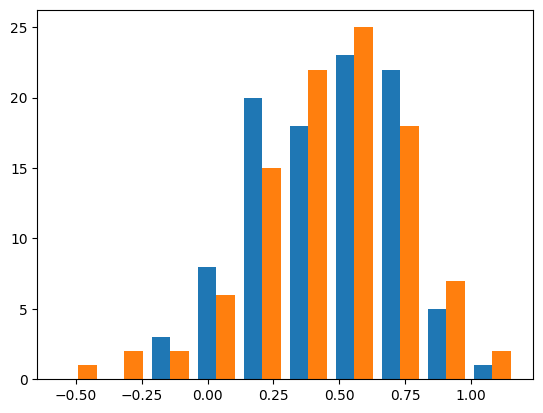

In [ ]:
plt.hist(ref.rsample((100,)))